# NYC PLUTO - PCA-First Clustering

**Purpose:** A self-contained clustering pipeline on the NYC PLUTO dataset that applies PCA
as a preprocessing step before clustering, and compares the PCA-space results against a
full-space baseline.

**Pipeline:**
- **Part 0 - Preprocessing and Standardization.** Builds the standardized clustering matrix
  directly from the raw PLUTO file (numeric conversion, coded-missing handling, outlier
  capping, feature engineering, log1p, StandardScaler) and writes the shared artifacts
  `X_scaled.csv`, `X_scaled_features.csv`, `pluto_companion.csv`, and `sample_index.csv`.
- **Part 1 - Data Loading, PCA, and K-Means.** Reduces the standardized matrix with PCA
  (about 90% cumulative variance) and runs K-Means in both PCA space and full space.
- **Part 2 - DBSCAN.** Re-tunes and fits DBSCAN in PCA space, with full-space baselines.
- **Part 3 - Comparison, Interpretation, Visualization.** Quantifies agreement between
  spaces and algorithms and interprets the clusters with original features.
- **Part 4 - Theory Questions and Coding Exercises.** Course tutorial answers and small
  toy-dataset exercises.

**Question:** Does applying PCA before clustering improve cluster compactness, separation,
or interpretability compared to the full-space baseline?


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
SILHOUETTE_SAMPLE_SIZE = 10_000

# Robust project-root detection, independent of any single notebook path
search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "data" / "processed").is_dir() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root (expected data/processed/ and requirements.txt).")

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "pluto_working_copy.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Shared artifact paths used across the three parts
X_SCALED_PATH = PROCESSED_DIR / "X_scaled.csv"
FEATURES_PATH = PROCESSED_DIR / "X_scaled_features.csv"
SAMPLE_INDEX_PATH = PROCESSED_DIR / "sample_index.csv"
SHARED_SAMPLE_INDEX_PATH = SAMPLE_INDEX_PATH  # alias used by Part 2
KMEANS_LABELS_PATH = PROCESSED_DIR / "cluster_labels.csv"
COMPANION_PATH = PROCESSED_DIR / "pluto_companion.csv"
DBSCAN_KMEANS_LABELS_PATH = PROCESSED_DIR / "dbscan_kmeans_sample_labels.csv"
DBSCAN_SELECTION_SUMMARY_PATH = PROCESSED_DIR / "dbscan_selection_summary.csv"

# This notebook only -- figure prefix and path
FIG_PREFIX = "pca_pipeline_"
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks" / "02_clustering" / "pca_then_clustering.ipynb"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figure prefix: {FIG_PREFIX}")

Project root: /Users/ouriouahba/Desktop/NYC_PLUTO
Processed data directory: data/processed
Figure prefix: pca_pipeline_


# Part 0 - Preprocessing and Standardization

This front-end regenerates the four shared artifacts (`X_scaled.csv`, `X_scaled_features.csv`, `pluto_companion.csv`, `sample_index.csv`) directly from the raw PLUTO file, so this notebook is self-contained.


## Section 1: Data Loading and Feature Role Definitions

In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'First 10 columns: {list(df_raw.columns[:10])}')

Dataset loaded: 858,644 rows, 101 columns
First 10 columns: ['borough', 'Tax block', 'Tax lot', 'community board', 'census tract 2010', 'cb2010', 'schooldist', 'council district', 'postcode', 'firecomp']


### Feature role definitions

Features are split into two non-overlapping roles before any transformation:

| Role | Features | Rationale |
|---|---|---|
| **Clustering input** | 13 source numerics + 3 engineered (16 total) | Measured physical and functional building characteristics |
| **Post-clustering only** | `borough`, `postcode`, `community board`, `latitude`, `longitude`, `assesstot`, `landuse` | Geographic, value, and categorical context reserved for blind validation after cluster assignment |

**Why exclude `borough` from clustering?**  
Borough is a coarse administrative label, not a building characteristic. Including it would bias K-Means toward geographic sub-regions rather than meaningful building typologies.

**Why exclude `landuse` from clustering?**  
`landuse` is a categorical label summarizing predominant use. Included as one-hot input, it dominates the distance calculation and K-Means simply recovers the input categories: cluster sizes mirror landuse-code frequencies rather than building morphology. `landuse` is instead used for blind validation - cross-tabulated against the discovered clusters in Section 9 to show what the morphology-based groups correspond to.

**Why exclude `assesstot` from clustering?**  
Total assessed value would reduce the segmentation to value-based groups, collapsing the problem into a form of regression. It is reserved for post-hoc cluster profiling.

In [3]:
# Source numeric columns needed before engineering
SOURCE_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'yearbuilt',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
]

# Engineered clustering features (derived below)
ENGINEERED = ['building_age', 'building_density', 'residential_ratio']

# Clustering features: 16 numeric dimensions only.
# landuse is intentionally excluded; see Section 6 for the rationale.
CLUSTER_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
    'building_age', 'building_density', 'residential_ratio',
]

# Columns that receive log1p before scaling
LOG_COLS = [
    'lotarea', 'bldgarea', 'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_density',
]

# Post-clustering interpretation columns (never fed to K-Means).
# landuse is here for blind post-hoc validation against discovered clusters.
POST_CLUSTER = [
    'borough', 'postcode', 'community board',
    'latitude', 'longitude', 'assesstot', 'landuse',
]

# Lot identifier
ID_COL = 'BBL'

# Columns to winsorize (IQR capping)
WINSORISE_COLS = ['lotfront', 'lotdepth', 'lotarea', 'bldgarea', 'unitstotal', 'resarea', 'yearbuilt']

# Columns to load from the raw CSV
LOAD_COLS = [ID_COL] + SOURCE_NUMERIC + POST_CLUSTER

# Verify all requested columns exist
missing_cols = [c for c in LOAD_COLS if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Columns not found in raw CSV: {missing_cols}')
print('All required columns present.')
print(f'Loading {len(LOAD_COLS)} columns from the raw dataset.')

df = df_raw[LOAD_COLS].copy()
print(f'Working frame shape: {df.shape}')

All required columns present.
Loading 22 columns from the raw dataset.
Working frame shape: (858644, 22)


## Section 2: Numeric Conversion and Coded-Missing Replacement

### 2.1 Numeric conversion

The raw CSV was exported with a Narrow No-Break Space (U+202F) as a thousands separator,
which is a French locale artifact. Values such as `"2 660"` must be stripped before conversion.
We use a regex that removes all whitespace variants (ASCII space, U+202F, U+00A0) and any
non-numeric character, then pass `errors='coerce'` so unparseable values become NaN.

In [4]:
# Strip thousands-separator whitespace and coerce to numeric
numeric_to_convert = SOURCE_NUMERIC + ['assesstot', 'latitude', 'longitude', 'postcode']

for col in numeric_to_convert:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
                   .str.replace(r'[\s\u202f\u00a0]', '', regex=True)
                   .str.replace(r'[^\d.\-]', '', regex=True)
                   .replace('', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversion complete.')
print('dtypes sample:')
print(df[SOURCE_NUMERIC[:6]].dtypes)

Numeric conversion complete.
dtypes sample:
lotarea      float64
bldgarea     float64
numfloors    float64
lotfront     float64
lotdepth     float64
yearbuilt    float64
dtype: object


### 2.2 Replace coded-missing zeros with NaN

The PLUTO data dictionary documents `yearbuilt = 0` as "year unknown" and `bldgarea = 0` as
an unpopulated field. Both encode absence of information, not a real measurement of zero.
Treating them as zero would pull centroids toward nonsensical values (an age of 2026 years,
a building with no floor area). Replacing them with NaN lets the missing-value drop in
Section 5 handle them correctly.

In [5]:
n_yearbuilt_zero = (df['yearbuilt'] == 0).sum()
n_bldgarea_zero  = (df['bldgarea']  == 0).sum()

df.loc[df['yearbuilt'] == 0, 'yearbuilt'] = np.nan
df.loc[df['bldgarea']  == 0, 'bldgarea']  = np.nan

print(f'yearbuilt == 0 replaced with NaN: {n_yearbuilt_zero:,} rows ({n_yearbuilt_zero/len(df)*100:.2f}%)')
print(f'bldgarea  == 0 replaced with NaN: {n_bldgarea_zero:,}  rows ({n_bldgarea_zero/len(df)*100:.2f}%)')

yearbuilt == 0 replaced with NaN: 40,115 rows (4.67%)
bldgarea  == 0 replaced with NaN: 41,109  rows (4.79%)


## Section 3: Outlier Capping (IQR Winsorization)

### Why cap rather than delete?

EDA Notebook 2 detected extreme right-skew and IQR outliers on several area and count features.
Deleting outlier rows would discard a large share of the dataset for some features; the intersection
across features would remove far more. Winsorization (capping at Q1 - 1.5*IQR and Q3 + 1.5*IQR)
retains every row and limits the influence of extreme values without discarding information.

The EDA outlier analysis ranks `lotdepth` and `lotfront` as
the two highest-outlier features by IQR-outlier share, followed by `numfloors`, `unitstotal`, `lotarea`, `bldgarea`,
`resarea`, and `yearbuilt`. All seven are winsorized with IQR capping here.
`numfloors` is handled separately: a hard cap at 104 floors removes parsing artifacts (One World
Trade Center is the tallest real building), supplemented by an additional landuse-1 sanity cap of
4 floors in Section 3b. This building-type-specific correction applies only to
one/two-family dwellings; other landuse codes (e.g. walk-up apartments, landuse 2)
retain potentially implausible floor counts, a deliberate scope choice.

In [6]:
# Hard cap: numfloors > 104 are data-entry artifacts, not real buildings
n_floors_capped = (df['numfloors'] > 104).sum()
df.loc[df['numfloors'] > 104, 'numfloors'] = np.nan
print(f'numfloors > 104 set to NaN: {n_floors_capped:,} rows')

# IQR winsorization for the seven highest-outlier features
cap_stats = []
for col in WINSORISE_COLS:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_lo = (df[col] < lo).sum()
    n_hi = (df[col] > hi).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    cap_stats.append({'feature': col, 'lower_cap': round(lo, 2), 'upper_cap': round(hi, 2),
                      'rows_capped_low': n_lo, 'rows_capped_high': n_hi})

print('\nIQR capping summary:')
print(pd.DataFrame(cap_stats).to_string(index=False))

numfloors > 104 set to NaN: 27,069 rows



IQR capping summary:
   feature  lower_cap  upper_cap  rows_capped_low  rows_capped_high
  lotfront     -262.5      501.5                0            185813
  lotdepth       14.5      242.5             2849            201785
   lotarea    -1000.0     7000.0                0             74061
  bldgarea     -987.5     5592.5                0             90052
unitstotal       -0.5        3.5                0            110558
   resarea     -590.0     4354.0                0             74429
 yearbuilt     1860.0     2020.0             4037              5911


In [7]:
# Diagnostic: numfloors distribution and implausible values by landuse code.
# Purpose: identify the scale of data-entry errors before choosing a cleaning rule.
# Note: values > 104 have already been set to NaN in the cell above.
print('numfloors summary (after cap at 104):')
print(df['numfloors'].describe().round(2))
print(f'Rows with numfloors NaN: {df["numfloors"].isna().sum():,}')

lu_totals = df['landuse'].value_counts().sort_index()

for t in [6, 10, 20]:
    above = df[df['numfloors'] > t]
    n_total = len(above)
    lu_above = above['landuse'].value_counts().sort_index()
    diag = pd.DataFrame({
        'count_above': lu_above,
        'pct_of_landuse': (lu_above / lu_totals * 100).round(1),
    }).dropna()
    print(f'\nnumfloors > {t}: {n_total:,} buildings ({n_total / len(df) * 100:.1f}% of all rows)')
    print(diag.to_string())

numfloors summary (after cap at 104):
count    789212.00
mean          5.28
std           7.50
min           0.00
25%           2.00
50%           2.00
75%           3.00
max         104.00
Name: numfloors, dtype: float64
Rows with numfloors NaN: 69,432

numfloors > 6: 117,620 buildings (13.7% of all rows)
         count_above  pct_of_landuse
landuse                             
1.0            99566            17.6
2.0             4143             3.1
3.0             4735            35.4
4.0             5312             9.4
5.0             2615            12.3
6.0              211             2.3
7.0               36             0.6
8.0              902             7.5
9.0                9             0.2
10.0              40             0.4
11.0               1             0.0

numfloors > 10: 111,630 buildings (13.0% of all rows)
         count_above  pct_of_landuse
landuse                             
1.0            99561            17.6
2.0             4031             3.1
3.0     

In [8]:
# Targeted numfloors correction: landuse 1 (one/two-family buildings) only.
# One and two-family homes cannot physically have more than 4 floors.
# Values above 4 for landuse 1 are data-entry errors, likely copied from an adjacent
# high-rise or entered at block level rather than building level.
# All other landuse codes are left untouched: genuine high-rises live in landuse 3
# (multi-family elevator) and must not be affected.
# Rows set to NaN here are removed at the existing dropna step in Section 5.
mask_lu1_high = (df['landuse'] == 1) & (df['numfloors'] > 4)
n_corrected = int(mask_lu1_high.sum())
df.loc[mask_lu1_high, 'numfloors'] = np.nan

print(f'numfloors > 4 set to NaN for landuse 1: {n_corrected:,} rows ({n_corrected / len(df) * 100:.2f}%)')
print('These rows will be removed at the dropna step (numfloors is a clustering feature).')

print('\nnumfloors summary after correction (landuse 1 capped at 4):')
print(df['numfloors'].describe().round(2))

print('\nSanity check - max numfloors by landuse after correction:')
print(df.groupby('landuse')['numfloors'].max().sort_index().round(1))

numfloors > 4 set to NaN for landuse 1: 100,238 rows (11.67%)
These rows will be removed at the dropna step (numfloors is a clustering feature).

numfloors summary after correction (landuse 1 capped at 4):
count    688974.00
mean          2.73
std           3.26
min           0.00
25%           2.00
50%           2.00
75%           3.00
max         104.00
Name: numfloors, dtype: float64

Sanity check - max numfloors by landuse after correction:
landuse
1.0       4.0
2.0      65.0
3.0      95.0
4.0      98.0
5.0     104.0
6.0      45.0
7.0      25.0
8.0      75.0
9.0      45.0
10.0     25.0
11.0     15.0
Name: numfloors, dtype: float64


## Section 4: Feature Engineering

Three derived features are created from the winsorized source columns, before any log transform.
This order matters: log1p compresses values, which would change the denominators and numerators
used in the ratios and the age computation.

| Feature | Formula | Interpretation |
|---|---|---|
| `building_age` | `2026 - yearbuilt` | Years elapsed since construction; 2026 is the analysis reference year |
| `building_density` | `bldgarea / lotarea` | Floor-area ratio proxy; how intensively a lot is built upon |
| `residential_ratio` | `clip(unitsres / unitstotal, 0, 1)` | Share of residential units; 0 = unit-less building, 1 = purely residential |

**NaN vs zero semantics for `residential_ratio`:**
A building with `unitstotal == 0` (e.g. a parking lot, vacant land, utility infrastructure)
has no units at all, making it 0% residential. This is a real, informative value, not missing
data. NaN is reserved strictly for rows where `unitstotal` or `unitsres` is itself absent
from the source.

**Clipping to [0, 1]:** `unitstotal` was winsorized (denominator capped at Q3 + 1.5*IQR)
but `unitsres` was not, so in some rows `unitsres` can exceed the winsorized `unitstotal`,
producing a ratio above 1. A building cannot be more than 100% residential by units, so
the ratio is clipped to [0, 1] after computation. This correction feeds through to the
clustering matrix and the cluster profiles.

Both ratio features use `np.where` with explicit NaN branches, and an extra `replace` call
removes any residual Inf values that could slip through winsorization near-zero edge cases
(`dropna` does not catch Inf).

**Traceability note:** the Phase 1 EDA defined `residential_ratio` but treated buildings with
`unitstotal == 0` as NaN. This notebook refines that definition by assigning 0.0 instead,
since a building with no units is genuinely 0% residential rather than missing information.

In [9]:
# building_age: yearbuilt already NaN where year was unknown (0)
df['building_age'] = 2026 - df['yearbuilt']

# building_density: NaN when lot has no area (np.where avoids inf)
df['building_density'] = np.where(
    df['lotarea'].notna() & (df['lotarea'] > 0),
    df['bldgarea'] / df['lotarea'],
    np.nan
)

# residential_ratio: unitsres / unitstotal (NOT resarea / bldgarea)
#   - NaN  when either unitstotal or unitsres is genuinely missing
#   - 0.0  when unitstotal == 0: the building has no units (parking lot, vacant land,
#          utility site); it is 0% residential, not missing information.
#   - ratio when unitstotal > 0, then clipped to [0, 1]
#
# Clipping is necessary because unitstotal (denominator) was winsorized but unitsres
# (numerator) was not. In rows where unitsres exceeds the capped unitstotal the raw
# ratio exceeds 1, which is physically impossible. clip(0, 1) corrects this without
# discarding the row, and the corrected value feeds both clustering and profiles.
df['residential_ratio'] = np.where(
    df['unitstotal'].isna() | df['unitsres'].isna(),
    np.nan,
    np.where(
        df['unitstotal'] > 0,
        df['unitsres'] / df['unitstotal'],
        0.0
    )
)
df['residential_ratio'] = df['residential_ratio'].clip(lower=0.0, upper=1.0)

# Safety: replace any Inf that could survive winsorization near-zero edges.
# dropna does not catch Inf, so this guard is necessary.
df[ENGINEERED] = df[ENGINEERED].replace([np.inf, -np.inf], np.nan)

# Confirm residential_ratio is bounded
rr = df['residential_ratio'].dropna()
print(f'residential_ratio range after clip: [{rr.min():.4f}, {rr.max():.4f}]  (must be [0, 1])')
print('Engineered feature statistics:')
df[ENGINEERED].describe().round(3)

residential_ratio range after clip: [0.0000, 1.0000]  (must be [0, 1])
Engineered feature statistics:


,building_age,building_density,residential_ratio
count,818203.000,816739.000,858199.000
mean,84.356,0.923,0.881
std,31.561,0.597,0.311
min,6.000,0.000,0.000
25%,66.000,0.525,1.000
50%,95.000,0.786,1.000
75%,106.000,1.142,1.000
max,166.000,90.202,1.000


## Section 5: Drop Rows with Missing Clustering Values

After coded-zero replacement and feature engineering, some rows still have NaN in at least one
clustering feature. K-Means cannot operate on missing values, and the only lossless option
at this stage is row removal. Imputation with the median (a common shortcut) would distort
cluster geometry by pulling missing-value rows toward the center of the distribution,
making them artificially similar to one another rather than reflecting their true profile.

A safety guard stops the pipeline if more than 30% of rows would be dropped.

In [10]:
# Clustering features: 16 numeric dimensions, no categorical columns
ALL_CLUSTER_COLS = CLUSTER_NUMERIC

n_before = len(df)
df_clean = df.dropna(subset=ALL_CLUSTER_COLS).reset_index(drop=True)
n_after  = len(df_clean)
n_dropped  = n_before - n_after
pct_dropped = n_dropped / n_before * 100

print(f'Rows before drop: {n_before:,}')
print(f'Rows after drop:  {n_after:,}')
print(f'Rows dropped:     {n_dropped:,} ({pct_dropped:.2f}%)')

if pct_dropped > 30:
    raise RuntimeError(
        f'Data loss too high: {pct_dropped:.1f}% of rows dropped (threshold 30%). '
        'Review imputation or column selection before proceeding.'
    )

print('Data loss is within the 30% threshold. Proceeding.')

Rows before drop: 858,644
Rows after drop:  682,515
Rows dropped:     176,129 (20.51%)
Data loss is within the 30% threshold. Proceeding.


## Section 5b: Log1p Transformation on Skewed Features

K-Means uses Euclidean distance. A feature like `lotarea` that spans several orders of magnitude
(hundreds to millions of square feet) dominates every distance calculation, rendering all other
features irrelevant to cluster assignment. `log1p(x) = log(1 + x)` compresses the scale while
safely handling zeros (unlike `log(x)`, which is undefined at 0) and preserving rank order.

Features **not** log-transformed: `numfloors`, `lotfront`, `lotdepth`, `building_age`,
`residential_ratio`. These are already on compact, approximately linear scales.

Note: the `skewness_pre_log` column in the table below is measured **after** IQR winsorization, not on the raw full dataset. The Phase 1 EDA reported much higher pre-winsorization skewness on the raw columns; winsorization substantially reduces skewness before log1p is applied.

In [11]:
# Compute skewness before transformation for documentation
skew_before = df_clean[LOG_COLS].skew().round(2)

df_log = df_clean.copy()
for col in LOG_COLS:
    df_log[col] = np.log1p(df_log[col])

skew_after = df_log[LOG_COLS].skew().round(2)

skew_comparison = pd.DataFrame({'skewness_pre_log': skew_before, 'skewness_log1p': skew_after})
print('Skewness before and after log1p:')
print(skew_comparison.to_string())

Skewness before and after log1p:
                  skewness_pre_log  skewness_log1p
lotarea                       1.29            0.37
bldgarea                      0.94            0.06
unitstotal                    0.36            0.01
unitsres                    117.43            2.44
resarea                       0.54           -3.04
comarea                     156.57            2.03
officearea                   78.81            5.17
retailarea                  141.21            2.89
garagearea                  174.67            8.44
strgearea                   201.51           10.11
building_density              2.39            0.71


In [12]:
# Zero-share diagnostic: log1p does not normalize zero-inflated distributions.
# Features where most buildings have none of that use type retain a large point mass
# at zero after log1p(0)=0, remaining highly non-normal.
zero_shares = (df_clean[LOG_COLS] == 0).mean().mul(100).round(1)
print('Share of zero values per log-transformed feature (before log1p):')
for col in LOG_COLS:
    flag = '  [majority zero]' if zero_shares[col] > 50 else ''
    print(f'  {col:<22} {zero_shares[col]:5.1f}%{flag}')

Share of zero values per log-transformed feature (before log1p):
  lotarea                  0.0%
  bldgarea                 0.0%
  unitstotal               0.3%
  unitsres                 7.0%
  resarea                  7.1%
  comarea                 84.2%  [majority zero]
  officearea              96.2%  [majority zero]
  retailarea              90.6%  [majority zero]
  garagearea              98.5%  [majority zero]
  strgearea               99.0%  [majority zero]
  building_density         0.0%


**Limitation: zero-inflated sparse-area features**

The log1p transformation compresses skewness effectively for `lotarea`, `bldgarea`, and
other features with few zeros. However, several commercial-area columns (`garagearea`,
`strgearea`, `officearea`, `retailarea`, `comarea`) have a large share of zero values:
most NYC buildings have no floor area dedicated to those uses. For these features,
`log1p(0) = 0`, so the transformed distribution retains a large point mass at zero and
remains highly non-normal despite the transformation. StandardScaler centers and scales
around that mass, but the dimension still differs structurally from a continuous feature.

This is a known limitation of the current feature set. A candidate refinement for a later
iteration would be to replace each sparse-area column with a binary presence flag
(1 if area > 0, 0 otherwise), which better captures the presence/absence signal. The
current 16-feature set is kept unchanged in this notebook.

## Section 6: Clustering Feature Matrix and Standardization

### Why landuse is excluded from the clustering features

`landuse` encodes the predominant use of a lot as a categorical code (1 = One/Two-Family,
5 = Commercial/Office, 6 = Industrial, etc.). Including it as a one-hot input causes two
compounding problems:

1. **Signal dominance.** Each binary column produced by one-hot encoding is exactly 0 or 1
   with no within-category variation. After StandardScaler the binary indicators carry
   disproportionate geometric weight relative to continuous physical features such as
   `bldgarea` or `numfloors`, which vary naturally within each land use type.

2. **Disguised re-labeling.** In practice, K-Means with one-hot landuse input recovers the
   input categories rather than discovering new structure. The cluster sizes mirror landuse-code
   frequencies, and the "segmentation" reports only what the original labels already encoded.

**Approach:** cluster on measured physical and functional building characteristics only (16
numeric features), then cross-tabulate the discovered clusters against `landuse` and `borough`
in Section 9 as a blind validation. If the discovered clusters correlate with land use, that
correlation is a finding, not an artifact of feeding the label in as input.

**Note on Phase 1 EDA recommendation:** The Phase 1 EDA synthesis recommended one-hot encoding
`landuse` as a clustering input. This notebook deliberately supersedes that recommendation:
feeding `landuse` as input causes K-Means to recover the input categories (disguised
re-labeling) rather than discovering new morphological structure, so it is reserved here
for blind post-hoc validation instead.

In [13]:
# Clustering matrix: 16 numeric features, no one-hot encoding.
# landuse is excluded to prevent recovering input labels as clusters.
df_encoded = df_log[CLUSTER_NUMERIC].copy()

print(f'Clustering matrix: {df_encoded.shape[0]:,} rows x {df_encoded.shape[1]} features')
print(list(df_encoded.columns))

Clustering matrix: 682,515 rows x 16 features


['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']


### 6.2 StandardScaler

After log transformation the distributions are approximately normal, but features still have
different variances; for example, floor counts and building age in years are measured on
different scales. Without scaling, features with higher variance dominate Euclidean distance. StandardScaler
transforms every feature to mean = 0 and std = 1, so each contributes equally to distance
regardless of its original unit.

The scaler is fitted on the full cleaned dataset (no train/test split for unsupervised learning)
and saved to disk with `joblib` so cluster centroids can be inverse-transformed in later notebooks.

In [14]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=df_encoded.columns,
    index=df_clean.index
)

# Save the fitted scaler for centroid inverse-transformation in later notebooks
scaler_path = PROCESSED_DIR / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'Scaler saved to {scaler_path.relative_to(PROJECT_ROOT)}')

print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Mean check (should be ~0): {X_scaled.mean().abs().max():.2e}')
print(f'Std check  (should be ~1): {X_scaled.std().mean():.4f}')

Scaler saved to data/processed/scaler.pkl
Scaled matrix shape: (682515, 16)
Mean check (should be ~0): 1.91e-15
Std check  (should be ~1): 1.0000


In [15]:
# Save the scaled clustering matrix
scaled_path = PROCESSED_DIR / 'X_scaled.csv'
X_scaled.to_csv(scaled_path, index=False)
print(f'Scaled matrix saved to {scaled_path.relative_to(PROJECT_ROOT)}')

# Save the ordered list of feature names for downstream alignment.
features_path = PROCESSED_DIR / 'X_scaled_features.csv'
pd.DataFrame({'feature': list(X_scaled.columns)}).to_csv(features_path, index=False)
print(f'Feature list saved to {features_path.relative_to(PROJECT_ROOT)}')

# Companion file: original (un-scaled) clustering values + all post-clustering columns + ID.
# POST_CLUSTER includes landuse for blind post-hoc cross-tabulation against clusters.
companion_cols = [ID_COL] + CLUSTER_NUMERIC + POST_CLUSTER
companion = df_clean[companion_cols].copy()

# value_per_sqft: post-clustering interpretation only (not a clustering feature).
# NaN where bldgarea is absent or zero to avoid divide-by-zero.
companion['value_per_sqft'] = np.where(
    companion['bldgarea'].notna() & (companion['bldgarea'] > 0),
    companion['assesstot'] / companion['bldgarea'],
    np.nan
)

companion_path = PROCESSED_DIR / 'pluto_companion.csv'
companion.to_csv(companion_path, index=True)
print(f'Companion file saved to {companion_path.relative_to(PROJECT_ROOT)}')
print(f'Companion shape: {companion.shape}')

Scaled matrix saved to data/processed/X_scaled.csv
Feature list saved to data/processed/X_scaled_features.csv


Companion file saved to data/processed/pluto_companion.csv
Companion shape: (682515, 25)


In [16]:
sample_idx = X_scaled.sample(n=50_000, random_state=RANDOM_STATE).index

# Save sample indices so downstream notebooks use the exact same 50,000 rows.
pd.Series(sample_idx, name='row_index').to_csv(
    PROCESSED_DIR / 'sample_index.csv', index=False
)

print(f'Sample drawn: {len(sample_idx):,} rows')
print(f'Sample index saved to:   {(PROCESSED_DIR / "sample_index.csv").relative_to(PROJECT_ROOT)}')


Sample drawn: 50,000 rows
Sample index saved to:   data/processed/sample_index.csv


# Part 1 - Data Loading, PCA, and K-Means

## Section 1: Load Validated Standardized Matrix and Shared Sample

In [17]:
# Load the full standardized matrix
X_scaled = pd.read_csv(X_SCALED_PATH)
feature_names = pd.read_csv(FEATURES_PATH).iloc[:, 0].tolist()

# Reconstruct exactly the same working sub-sample as the baseline notebook
# (Part 2, cell logic: rng draws SAMPLE_SIZE positions from the shared index)
rng = np.random.RandomState(RANDOM_STATE)

if SHARED_SAMPLE_INDEX_PATH.exists():
    shared_sample_idx = pd.read_csv(SHARED_SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if shared_sample_idx.min() < 0 or shared_sample_idx.max() >= len(X_scaled):
        raise ValueError("sample_index.csv contains row positions outside X_scaled.")
    subset_size = min(SAMPLE_SIZE, len(shared_sample_idx))
    selected_positions = rng.choice(len(shared_sample_idx), size=subset_size, replace=False)
    sample_idx = shared_sample_idx[selected_positions]
    sample_source = f"{subset_size:,} rows drawn from existing shared sample_index.csv"
else:
    subset_size = min(SAMPLE_SIZE, len(X_scaled))
    sample_idx = rng.choice(X_scaled.index.to_numpy(), size=subset_size, replace=False)
    pd.DataFrame({"row_index": sample_idx}).to_csv(SHARED_SAMPLE_INDEX_PATH, index=False)
    selected_positions = np.arange(subset_size)
    sample_source = f"created {subset_size:,}-row sample_index.csv from X_scaled"

X_sample = X_scaled.iloc[sample_idx].copy()
X_sample_array = X_sample.to_numpy(dtype=np.float32)

# Companion: align unstandardized original features to the same rows
companion = pd.read_csv(COMPANION_PATH)
companion_sample = companion.iloc[sample_idx].copy().reset_index(drop=True)

# Sanity check
print(f"X_scaled full matrix : {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Working sub-sample   : {X_sample.shape[0]:,} rows  ({sample_source})")
print(f"Number of features   : {len(feature_names)}")
print(f"Feature names        : {feature_names}")
print()
X_sample.head()

X_scaled full matrix : 682,515 rows x 16 features
Working sub-sample   : 10,000 rows  (10,000 rows drawn from existing shared sample_index.csv)
Number of features   : 16
Feature names        : ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']



,lotarea,bldgarea,numfloors,lotfront,lotdepth,unitstotal,unitsres,resarea,comarea,officearea,retailarea,garagearea,strgearea,building_age,building_density,residential_ratio
307260,0.953701,0.001085,0.086105,-0.570180,1.698467,0.163350,-0.024466,0.354120,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-2.328054,-0.827909,0.329387
682384,0.397686,-1.247706,-0.223780,-0.670579,1.698467,0.163350,-0.024466,0.023515,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.715197,-1.287588,0.329387
298347,-1.204888,-1.378412,-0.223780,0.007117,-0.540113,-1.125912,-0.552841,-0.011088,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-1.475944,-0.414175,0.329387
201850,-1.204888,0.378191,0.086105,-0.670579,1.698467,1.078096,-0.024466,0.251211,1.847925,-0.194941,2.724609,-0.120596,-0.101129,0.380440,1.445542,-0.936491
333938,1.052740,-0.717179,-0.223780,-0.560140,-0.430148,-1.125912,-0.552841,0.163967,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.106547,-1.315069,0.329387


## Section 2: PCA as Preprocessing (dynamic ~90% variance)

### Why apply PCA before clustering?

**Correlated features inflate distances.** The 16-dimensional standardized space contains groups of features that share most of their variance: residential area and residential unit count move almost in lockstep, and the commercial area breakdowns (total commercial, office, retail) overlap substantially. In distance-based algorithms such as K-Means and DBSCAN, collinear dimensions count multiple times, skewing the notion of "closeness" and making cluster boundaries harder to separate.

**Multi-component reduction, not a 2D projection.** The goal here is to keep enough principal components to retain approximately 90% of the total variance. The number of components is determined dynamically by the data; the 2D projection is reserved for the final visualization section only and is never used as the clustering space.

**PCA maximises variance, not cluster separation.** Principal components are oriented toward directions of maximum spread, which does not guarantee that the compressed representation improves cluster quality. This is a methodological limit: we will verify the outcome with silhouette scores and an ARI comparison against the full-space baseline, rather than assuming an improvement up front.

**The safeguard against label leakage is preserved.** PCA is applied to `X_scaled`, which already excludes `landuse`, `borough`, and all other post-clustering descriptors. No administrative label is smuggled into the cluster geometry.

In [18]:
# Full-rank PCA to find how many components reach 90% cumulative variance
pca_search = PCA(random_state=RANDOM_STATE)
pca_search.fit(X_scaled)

cumvar = np.cumsum(pca_search.explained_variance_ratio_)
n_components_pca = int(np.searchsorted(cumvar, 0.90)) + 1

print(f"Components needed to reach 90% cumulative variance : {n_components_pca}")
print(f"Cumulative variance at {n_components_pca} components         : {cumvar[n_components_pca - 1] * 100:.2f}%")

Components needed to reach 90% cumulative variance : 10
Cumulative variance at 10 components         : 92.19%


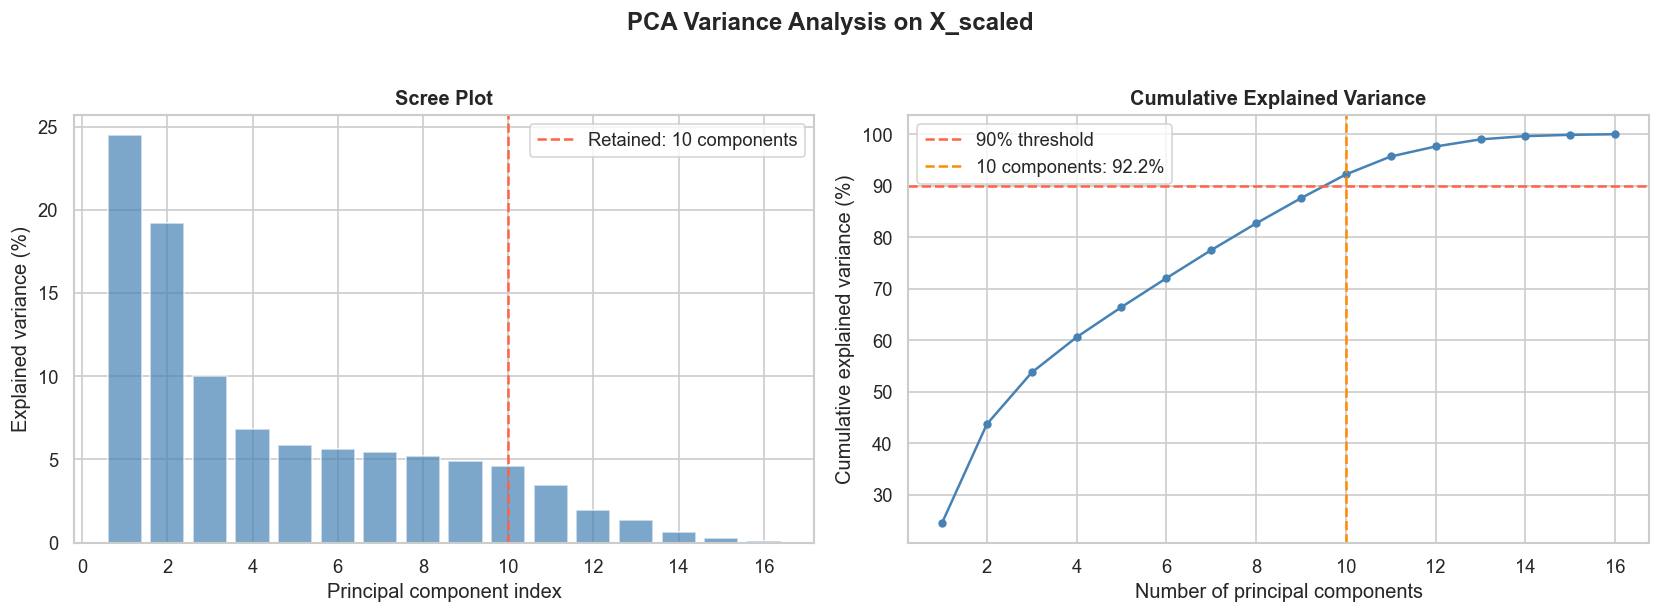

Figure saved: reports/figures/pca_pipeline_variance.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot (per-component explained variance)
ax = axes[0]
ax.bar(
    range(1, len(pca_search.explained_variance_ratio_) + 1),
    pca_search.explained_variance_ratio_ * 100,
    color="steelblue", alpha=0.7
)
ax.axvline(n_components_pca, color="tomato", linestyle="--",
           label=f"Retained: {n_components_pca} components")
ax.set_xlabel("Principal component index")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree Plot", fontweight="bold")
ax.legend()

# Right: cumulative variance curve with 90% threshold
ax = axes[1]
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=4, color="steelblue")
ax.axhline(90, color="tomato", linestyle="--", label="90% threshold")
ax.axvline(n_components_pca, color="darkorange", linestyle="--",
           label=f"{n_components_pca} components: {cumvar[n_components_pca - 1] * 100:.1f}%")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Cumulative Explained Variance", fontweight="bold")
ax.legend()

plt.suptitle("PCA Variance Analysis on X_scaled", fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / f"{FIG_PREFIX}variance.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path.relative_to(PROJECT_ROOT)}")

In [20]:
# Final PCA fit with the retained number of components
pca_pipeline = PCA(n_components=n_components_pca, random_state=RANDOM_STATE)
X_pca_full_array = pca_pipeline.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    X_pca_full_array,
    index=X_scaled.index,
    columns=[f"PC{i + 1}" for i in range(n_components_pca)]
)

# Align to the same sub-sample rows defined in Section 1
X_pca_sample = X_pca.iloc[sample_idx].copy()

print(f"X_pca (full matrix) shape  : {X_pca.shape}")
print(f"X_pca_sample shape         : {X_pca_sample.shape}")
print(f"X_sample shape (full-space): {X_sample.shape}")
print()
print("First rows of X_pca_sample:")
X_pca_sample.head()

X_pca (full matrix) shape  : (682515, 10)
X_pca_sample shape         : (10000, 10)
X_sample shape (full-space): (10000, 16)

First rows of X_pca_sample:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
307260,-0.457336,-0.232026,2.063813,0.495843,0.352083,0.127011,-1.098602,0.305365,-1.448852,1.486487
682384,-0.913109,-0.575545,0.575631,0.918990,-0.106738,-0.730401,1.424979,-0.028075,-0.699392,1.021778
298347,-1.608485,-1.412163,-0.291830,-0.105436,-0.220781,1.028656,-1.118270,0.581107,0.405284,0.515566
201850,2.497057,1.288477,-2.168860,0.220672,-0.647834,-0.568769,-0.447541,-0.456204,-0.336607,2.221748
333938,-1.237582,-1.485964,0.959554,-0.426490,-0.014685,-0.758328,0.524777,-0.081382,0.142294,0.025062


## Section 3: K-Means on PCA Components

### K-Means cluster count selection in PCA space

**Decision rule, fixed in advance.** The value of k is chosen as the one that maximises the silhouette score computed on `X_pca_sample`, the 10-component PCA space where K-Means actually runs. The rule is set before any result is computed and is not adjusted post-hoc.

**Two additional metrics are reported as independent checks.** Calinski-Harabasz (higher is better: measures the ratio of between-cluster to within-cluster dispersion) and Davies-Bouldin (lower is better: measures average cluster similarity) are computed for every k and displayed in the table below. They do not participate in the decision; they only show whether the silhouette winner is confirmed or contradicted by the other criteria.

**Cross-space silhouette comparisons are indicative only.** A silhouette computed in 10 dimensions is not numerically comparable to one computed in 16 dimensions because Euclidean distances scale differently with dimensionality. Ranking k within each space is meaningful; comparing absolute magnitudes across spaces is not. The true equivalence test -- whether the two partitions agree on the same observations -- is measured by the Adjusted Rand Index in Section 6.

In [21]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

k_range = range(2, 9)
inertias_pca    = []
silhouettes_pca = []
ch_pca          = []
db_pca          = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca_sample)
    inertias_pca.append(km.inertia_)
    sil = silhouette_score(X_pca_sample, labels,
                           sample_size=SILHOUETTE_SAMPLE_SIZE,
                           random_state=RANDOM_STATE)
    silhouettes_pca.append(sil)
    ch_pca.append(calinski_harabasz_score(X_pca_sample, labels))
    db_pca.append(davies_bouldin_score(X_pca_sample, labels))

results_pca = pd.DataFrame({
    'k':                list(k_range),
    'inertia':          [round(v, 1) for v in inertias_pca],
    'silhouette':       [round(v, 4) for v in silhouettes_pca],
    'calinski_harabasz':[round(v, 1) for v in ch_pca],
    'davies_bouldin':   [round(v, 4) for v in db_pca],
}).set_index('k')

print("PCA space -- all k, four metrics:")
print(results_pca.to_string())

best_k_pca_idx = int(np.argmax(silhouettes_pca))
best_k_pca     = list(k_range)[best_k_pca_idx]
print(f"\nbest_k_pca (argmax silhouette) = {best_k_pca}")

PCA space -- all k, four metrics:
    inertia  silhouette  calinski_harabasz  davies_bouldin
k                                                         
2  113993.1      0.4729             2674.4          1.6408
3   93648.2      0.3079             2713.5          1.4990
4   85285.4      0.2501             2312.9          1.5316
5   78234.6      0.2545             2116.0          1.4400
6   71325.1      0.2190             2050.2          1.4105
7   64935.4      0.2452             2040.4          1.2643
8   61358.9      0.2207             1933.8          1.3099

best_k_pca (argmax silhouette) = 2


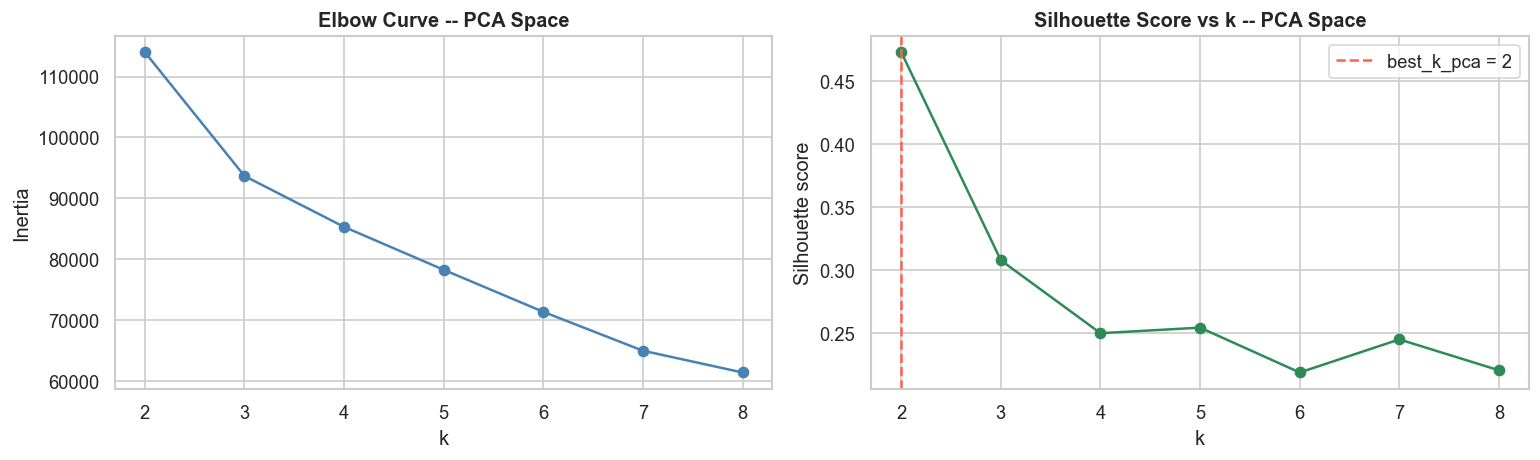

Figure saved: reports/figures/pca_pipeline_kmeans_selection.png


In [22]:
k_list = list(k_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_list, inertias_pca, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve -- PCA Space', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_list)

axes[1].plot(k_list, silhouettes_pca, marker='o', color='seagreen')
axes[1].axvline(best_k_pca, linestyle='--', color='tomato',
                label=f'best_k_pca = {best_k_pca}')
axes[1].set_title('Silhouette Score vs k -- PCA Space', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(k_list)
axes[1].legend()

plt.tight_layout()
fig_path = FIGURES_DIR / f'{FIG_PREFIX}kmeans_selection.png'
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path.relative_to(PROJECT_ROOT)}')

In [23]:
km_pca_final = KMeans(n_clusters=best_k_pca, init='k-means++', n_init=10,
                      max_iter=300, random_state=RANDOM_STATE)
labels_pca_kmeans = km_pca_final.fit_predict(X_pca_sample)

final_sil_pca = silhouette_score(X_pca_sample, labels_pca_kmeans,
                                 sample_size=SILHOUETTE_SAMPLE_SIZE,
                                 random_state=RANDOM_STATE)
vals, cnts = np.unique(labels_pca_kmeans, return_counts=True)
print(f'Final K-Means -- PCA space')
print(f'  k            : {best_k_pca}')
print(f'  Silhouette   : {final_sil_pca:.4f}')
print(f'  Cluster sizes: {dict(zip(vals.tolist(), cnts.tolist()))}')

Final K-Means -- PCA space
  k            : 2
  Silhouette   : 0.4729
  Cluster sizes: {0: 8481, 1: 1519}


## Section 3b: Full-Space K-Means Baseline

### Full-space K-Means baseline

The same protocol -- fixed decision rule (argmax silhouette on range(2, 9)), same four metrics, same hyperparameters -- is applied to `X_sample`, the 16-dimensional standardized space on the identical set of rows. This produces a directly comparable baseline: any difference in chosen k or cluster structure reflects the change of representation, not sampling variability.

In [24]:
inertias_full    = []
silhouettes_full = []
ch_full          = []
db_full          = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_sample)
    inertias_full.append(km.inertia_)
    sil = silhouette_score(X_sample, labels,
                           sample_size=SILHOUETTE_SAMPLE_SIZE,
                           random_state=RANDOM_STATE)
    silhouettes_full.append(sil)
    ch_full.append(calinski_harabasz_score(X_sample, labels))
    db_full.append(davies_bouldin_score(X_sample, labels))

results_full = pd.DataFrame({
    'k':                list(k_range),
    'inertia':          [round(v, 1) for v in inertias_full],
    'silhouette':       [round(v, 4) for v in silhouettes_full],
    'calinski_harabasz':[round(v, 1) for v in ch_full],
    'davies_bouldin':   [round(v, 4) for v in db_full],
}).set_index('k')

print("Full space -- all k, four metrics:")
print(results_full.to_string())

best_k_full_idx = int(np.argmax(silhouettes_full))
best_k_full     = list(k_range)[best_k_full_idx]
print(f"\nbest_k_full (argmax silhouette) = {best_k_full}")

km_full_final = KMeans(n_clusters=best_k_full, init='k-means++', n_init=10,
                        max_iter=300, random_state=RANDOM_STATE)
labels_full_kmeans = km_full_final.fit_predict(X_sample)

final_sil_full = silhouette_score(X_sample, labels_full_kmeans,
                                  sample_size=SILHOUETTE_SAMPLE_SIZE,
                                  random_state=RANDOM_STATE)
vals2, cnts2 = np.unique(labels_full_kmeans, return_counts=True)
print(f'\nFinal K-Means -- full space')
print(f'  k            : {best_k_full}')
print(f'  Silhouette   : {final_sil_full:.4f}')
print(f'  Cluster sizes: {dict(zip(vals2.tolist(), cnts2.tolist()))}')

Full space -- all k, four metrics:
    inertia  silhouette  calinski_harabasz  davies_bouldin
k                                                         
2  126177.7      0.4676             2429.9          1.7384
3  105419.7      0.2939             2438.3          1.5903
4   96225.9      0.2234             2099.0          1.7068
5   88550.9      0.2396             1927.1          1.5414
6   82129.3      0.2194             1818.3          1.4343
7   76677.6      0.2283             1741.3          1.4254
8   72353.0      0.1723             1666.9          1.4492

best_k_full (argmax silhouette) = 2



Final K-Means -- full space
  k            : 2
  Silhouette   : 0.4676
  Cluster sizes: {0: 8481, 1: 1519}


In [25]:
print("K-Means selection summary")
print("-" * 44)
print(f"  PCA space  (10 dims) : best_k = {best_k_pca:>2}  |  silhouette = {final_sil_pca:.4f}")
print(f"  Full space (16 dims) : best_k = {best_k_full:>2}  |  silhouette = {final_sil_full:.4f}")
print("-" * 44)
if best_k_pca == best_k_full:
    print("Both spaces select the same k.")
else:
    print(f"Spaces diverge: PCA chose k={best_k_pca}, full space chose k={best_k_full}.")

K-Means selection summary
--------------------------------------------
  PCA space  (10 dims) : best_k =  2  |  silhouette = 0.4729
  Full space (16 dims) : best_k =  2  |  silhouette = 0.4676
--------------------------------------------
Both spaces select the same k.


# Part 2 - DBSCAN on PCA Components

## Section 4: DBSCAN Re-Tuning in PCA Space (new k-distance plot)

### Re-tuning DBSCAN in PCA space

**Why re-tune?** DBSCAN is distance-sensitive: the neighbourhood radius `eps` depends on the scale of pairwise distances in the space where the algorithm runs. Projecting onto 10 principal components changes those distances -- variance is redistributed across fewer dimensions and the coordinate scale shifts. Any `eps` calibrated in the 16-dimensional standardized space is meaningless here.

**Fixed procedure, identical in both spaces.** Two parameters are derived deterministically:

- `min_samples` = 2 times the number of dimensions of the space in question (PCA: 2 x 10; full: 2 x 16). This is a standard rule of thumb that scales the density threshold with dimensionality.
- `eps` = the elbow of the k-distance curve, located by the geometric method: normalize both axes of the sorted k-distance plot to [0, 1], measure the perpendicular distance from each point to the diagonal, take the index of the maximum. No manual adjustment, no import of a value from the other space.

min_samples_pca = 20  (2 x 10 PCA components)
eps_pca (geometric elbow)  = 1.7517


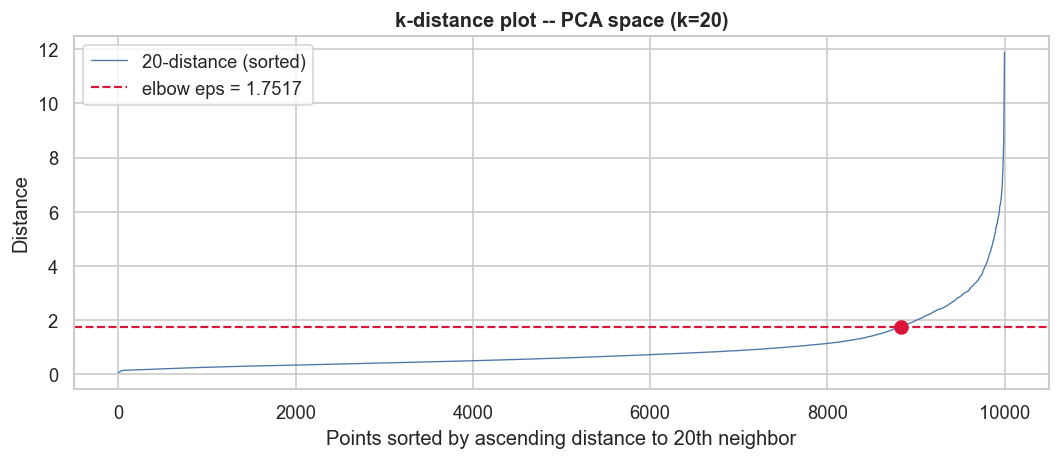

Figure saved: reports/figures/pca_pipeline_dbscan_kdistance_pca.png


In [26]:
from sklearn.neighbors import NearestNeighbors

# Fixed rule: min_samples = 2 * number of dimensions in this space
min_samples_pca = 2 * n_components_pca
print(f"min_samples_pca = {min_samples_pca}  (2 x {n_components_pca} PCA components)")

# k-distance curve in PCA space
nn_pca = NearestNeighbors(n_neighbors=min_samples_pca, n_jobs=-1)
nn_pca.fit(X_pca_sample.to_numpy())
kd_raw_pca, _ = nn_pca.kneighbors(X_pca_sample.to_numpy())
kd_sorted_pca = np.sort(kd_raw_pca[:, -1])

# Geometric elbow: argmax of perpendicular distance to the diagonal
_n = len(kd_sorted_pca)
_x_norm = np.linspace(0, 1, _n)
_y_norm = (kd_sorted_pca - kd_sorted_pca.min()) / (kd_sorted_pca.max() - kd_sorted_pca.min())
_perp   = np.abs(_y_norm - _x_norm) / np.sqrt(2)
_elbow_idx_pca = int(np.argmax(_perp))
eps_pca = float(kd_sorted_pca[_elbow_idx_pca])

print(f"eps_pca (geometric elbow)  = {eps_pca:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(_n), kd_sorted_pca, color='#4C78A8', linewidth=0.8,
        label=f'{min_samples_pca}-distance (sorted)')
ax.axhline(eps_pca, color='crimson', linestyle='--', linewidth=1.3,
           label=f'elbow eps = {eps_pca:.4f}')
ax.scatter([_elbow_idx_pca], [eps_pca], color='crimson', zorder=5, s=60)
ax.set_xlabel(f'Points sorted by ascending distance to {min_samples_pca}th neighbor')
ax.set_ylabel('Distance')
ax.set_title(f'k-distance plot -- PCA space (k={min_samples_pca})', fontweight='bold')
ax.legend()
plt.tight_layout()
fig_path = FIGURES_DIR / f'{FIG_PREFIX}dbscan_kdistance_pca.png'
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path.relative_to(PROJECT_ROOT)}')

In [27]:
def summarize_dbscan(labels, X, silhouette_sample_size=SILHOUETTE_SAMPLE_SIZE):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int((labels == -1).sum())
    noise_pct   = noise_count / len(labels) * 100
    if n_clusters >= 2 and non_noise_mask.sum() > 100:
        sil = silhouette_score(
            X[non_noise_mask], labels[non_noise_mask],
            sample_size=min(silhouette_sample_size, int(non_noise_mask.sum())),
            random_state=RANDOM_STATE,
        )
    else:
        sil = np.nan
    return {"n_clusters": n_clusters, "noise_count": noise_count,
            "noise_pct": noise_pct, "silhouette": sil}

# Compute per-min_samples elbows for the grid
_ms_values = [n_components_pca, 2 * n_components_pca]
_elbow_per_ms = {}
for _ms in _ms_values:
    _nn_g = NearestNeighbors(n_neighbors=_ms, n_jobs=-1).fit(X_pca_sample.to_numpy())
    _kd_g, _ = _nn_g.kneighbors(X_pca_sample.to_numpy())
    _kd_s = np.sort(_kd_g[:, -1])
    _N = len(_kd_s)
    _xn = np.linspace(0, 1, _N)
    _yn = (_kd_s - _kd_s.min()) / (_kd_s.max() - _kd_s.min())
    _ep = float(_kd_s[int(np.argmax(np.abs(_yn - _xn) / np.sqrt(2)))])
    _elbow_per_ms[_ms] = _ep

_scale_factors = [0.8, 1.0, 1.2]
rows = []
X_pca_arr = X_pca_sample.to_numpy()
for _ms in _ms_values:
    _base_eps = _elbow_per_ms[_ms]
    for _sf in _scale_factors:
        _eps = round(_base_eps * _sf, 4)
        _labels = DBSCAN(eps=_eps, min_samples=_ms, n_jobs=-1).fit_predict(X_pca_arr)
        _s = summarize_dbscan(_labels, X_pca_arr)
        rows.append({
            'min_samples': _ms,
            'eps_factor':  _sf,
            'eps':         _eps,
            'n_clusters':  _s['n_clusters'],
            'noise_pct':   round(_s['noise_pct'], 2),
            'silhouette':  round(_s['silhouette'], 4) if not np.isnan(_s['silhouette']) else float('nan'),
        })

grid_pca = pd.DataFrame(rows)
print("Sensitivity grid -- PCA space (all configs shown):")
print(grid_pca.to_string(index=False))

Sensitivity grid -- PCA space (all configs shown):
 min_samples  eps_factor    eps  n_clusters  noise_pct  silhouette
          10         0.8 1.0826          15      11.56      0.3256
          10         1.0 1.3532          11       9.03      0.3306
          10         1.2 1.6239          10       7.11      0.3926
          20         0.8 1.4013           7      11.07      0.3707
          20         1.0 1.7517           7       8.29      0.3715
          20         1.2 2.1020           4       6.20      0.3444


## Section 5: DBSCAN Final Fit on PCA Components

### Primary DBSCAN fit in PCA space

The configuration selected by the fixed rule is `(eps_pca, min_samples_pca)`: the elbow-derived eps and the dimension-scaled min_samples. No manual adjustment is applied.

In [28]:
labels_pca_dbscan = DBSCAN(eps=eps_pca, min_samples=min_samples_pca,
                            n_jobs=-1).fit_predict(X_pca_sample.to_numpy())
sum_pca_dbscan = summarize_dbscan(labels_pca_dbscan, X_pca_sample.to_numpy())

print(f"DBSCAN -- PCA space  (eps={eps_pca:.4f}, min_samples={min_samples_pca})")
print(f"  Clusters (excl. noise) : {sum_pca_dbscan['n_clusters']}")
print(f"  Noise points           : {sum_pca_dbscan['noise_count']:,} "
      f"({sum_pca_dbscan['noise_pct']:.2f}%)")
sil_str = (f"{sum_pca_dbscan['silhouette']:.4f}"
           if not np.isnan(sum_pca_dbscan['silhouette']) else 'not valid (< 2 clusters)')
print(f"  Silhouette (non-noise) : {sil_str}")

DBSCAN -- PCA space  (eps=1.7517, min_samples=20)
  Clusters (excl. noise) : 7
  Noise points           : 829 (8.29%)
  Silhouette (non-noise) : 0.3715


## Section 5b: Full-Space DBSCAN Baseline

### Full-space DBSCAN baseline

The same symmetric procedure is applied to `X_sample`, the 16-dimensional standardized space on the identical rows. `min_samples` and `eps` are derived independently from the full-space k-distance curve; no value is imported from the PCA-space analysis.

min_samples_full = 32  (2 x 16 features)
eps_full (geometric elbow)  = 2.1705


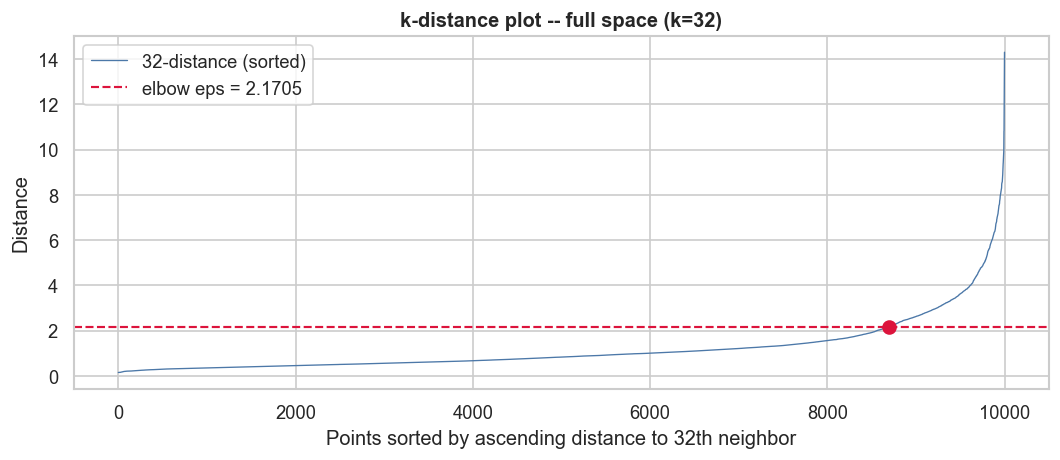

Figure saved: reports/figures/pca_pipeline_dbscan_kdistance_full.png



DBSCAN -- full space  (eps=2.1705, min_samples=32)
  Clusters (excl. noise) : 4
  Noise points           : 948 (9.48%)
  Silhouette (non-noise) : 0.4149


In [29]:
# Fixed rule: min_samples = 2 * number of features in full space
min_samples_full = 2 * X_sample.shape[1]
print(f"min_samples_full = {min_samples_full}  (2 x {X_sample.shape[1]} features)")

# k-distance curve in full space
X_sample_arr = X_sample.to_numpy()
nn_full = NearestNeighbors(n_neighbors=min_samples_full, n_jobs=-1)
nn_full.fit(X_sample_arr)
kd_raw_full, _ = nn_full.kneighbors(X_sample_arr)
kd_sorted_full = np.sort(kd_raw_full[:, -1])

_N = len(kd_sorted_full)
_xn = np.linspace(0, 1, _N)
_yn = (kd_sorted_full - kd_sorted_full.min()) / (kd_sorted_full.max() - kd_sorted_full.min())
_elbow_idx_full = int(np.argmax(np.abs(_yn - _xn) / np.sqrt(2)))
eps_full = float(kd_sorted_full[_elbow_idx_full])

print(f"eps_full (geometric elbow)  = {eps_full:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(_N), kd_sorted_full, color='#4C78A8', linewidth=0.8,
        label=f'{min_samples_full}-distance (sorted)')
ax.axhline(eps_full, color='crimson', linestyle='--', linewidth=1.3,
           label=f'elbow eps = {eps_full:.4f}')
ax.scatter([_elbow_idx_full], [eps_full], color='crimson', zorder=5, s=60)
ax.set_xlabel(f'Points sorted by ascending distance to {min_samples_full}th neighbor')
ax.set_ylabel('Distance')
ax.set_title(f'k-distance plot -- full space (k={min_samples_full})', fontweight='bold')
ax.legend()
plt.tight_layout()
fig_path_full = FIGURES_DIR / f'{FIG_PREFIX}dbscan_kdistance_full.png'
plt.savefig(fig_path_full, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path_full.relative_to(PROJECT_ROOT)}')

# Final fit full space
labels_full_dbscan = DBSCAN(eps=eps_full, min_samples=min_samples_full,
                              n_jobs=-1).fit_predict(X_sample_arr)
sum_full_dbscan = summarize_dbscan(labels_full_dbscan, X_sample_arr)

print(f"\nDBSCAN -- full space  (eps={eps_full:.4f}, min_samples={min_samples_full})")
print(f"  Clusters (excl. noise) : {sum_full_dbscan['n_clusters']}")
print(f"  Noise points           : {sum_full_dbscan['noise_count']:,} "
      f"({sum_full_dbscan['noise_pct']:.2f}%)")
sil_str = (f"{sum_full_dbscan['silhouette']:.4f}"
           if not np.isnan(sum_full_dbscan['silhouette']) else 'not valid (< 2 clusters)')
print(f"  Silhouette (non-noise) : {sil_str}")

In [30]:
summary_rows = [
    {
        'space':           'PCA (10 dims)',
        'min_samples':     min_samples_pca,
        'eps':             round(eps_pca, 4),
        'n_clusters':      sum_pca_dbscan['n_clusters'],
        'noise_pct':       round(sum_pca_dbscan['noise_pct'], 2),
        'silhouette':      (round(sum_pca_dbscan['silhouette'], 4)
                            if not np.isnan(sum_pca_dbscan['silhouette']) else float('nan')),
    },
    {
        'space':           'Full (16 dims)',
        'min_samples':     min_samples_full,
        'eps':             round(eps_full, 4),
        'n_clusters':      sum_full_dbscan['n_clusters'],
        'noise_pct':       round(sum_full_dbscan['noise_pct'], 2),
        'silhouette':      (round(sum_full_dbscan['silhouette'], 4)
                            if not np.isnan(sum_full_dbscan['silhouette']) else float('nan')),
    },
]
dbscan_comparison = pd.DataFrame(summary_rows).set_index('space')
print("DBSCAN final configuration -- side-by-side comparison:")
print(dbscan_comparison.to_string())

DBSCAN final configuration -- side-by-side comparison:
                min_samples     eps  n_clusters  noise_pct  silhouette
space                                                                 
PCA (10 dims)            20  1.7517           7       8.29      0.3715
Full (16 dims)           32  2.1705           4       9.48      0.4149


## Section 5c: Matched-min_samples Comparison (isolating the effect of the space)

### Why hold min_samples constant?

`min_samples` is a count of neighbours with no unit: it expresses how many points must surround a core point for it to be considered dense, independently of any coordinate scale. It is therefore directly comparable across spaces with different dimensionality.

`eps`, by contrast, is a distance threshold. Its meaningful value depends entirely on the scale of pairwise distances in the space where DBSCAN runs, which changes when the representation changes. The two quantities must be treated separately.

In Sections 5 and 5b, `min_samples` differed between spaces (20 vs the full-space value derived from 2 x the feature count). The resulting difference in cluster count could come from the change of representation, from the change of `min_samples`, or from both. This section removes that ambiguity by fixing `min_samples` at the PCA-space value in both spaces and re-deriving `eps` independently in each space by the same geometric elbow method. The only variable that then differs between the two runs is the space itself.

In [31]:
# Matched min_samples = 2 * n_components_pca (already used in PCA space)
_matched_ms = 2 * n_components_pca
print(f"Fixed min_samples for both spaces: {_matched_ms}")

# PCA side: config already computed -- reuse directly
print(f"\nPCA space  (existing config):")
print(f"  min_samples : {min_samples_pca}")
print(f"  eps         : {eps_pca:.4f}")
_pca_sum = summarize_dbscan(labels_pca_dbscan, X_pca_sample.to_numpy())
print(f"  n_clusters  : {_pca_sum['n_clusters']}")
print(f"  noise_pct   : {_pca_sum['noise_pct']:.2f}%")
_pca_sil = (f"{_pca_sum['silhouette']:.4f}"
            if not np.isnan(_pca_sum['silhouette']) else 'not valid')
print(f"  silhouette  : {_pca_sil}")

# Full space side: re-derive eps at k=20 from scratch
X_sample_arr = X_sample.to_numpy()
nn_matched = NearestNeighbors(n_neighbors=_matched_ms, n_jobs=-1)
nn_matched.fit(X_sample_arr)
kd_raw_m, _ = nn_matched.kneighbors(X_sample_arr)
kd_sorted_m = np.sort(kd_raw_m[:, -1])

_N = len(kd_sorted_m)
_xn = np.linspace(0, 1, _N)
_yn = (kd_sorted_m - kd_sorted_m.min()) / (kd_sorted_m.max() - kd_sorted_m.min())
_elbow_idx_m = int(np.argmax(np.abs(_yn - _xn) / np.sqrt(2)))
eps_full_k20 = float(kd_sorted_m[_elbow_idx_m])

print(f"\nFull space (min_samples={_matched_ms}, new k-distance elbow):")
print(f"  eps_full_k20 : {eps_full_k20:.4f}")

labels_full_dbscan_matched = DBSCAN(eps=eps_full_k20, min_samples=_matched_ms,
                                     n_jobs=-1).fit_predict(X_sample_arr)
_full_m_sum = summarize_dbscan(labels_full_dbscan_matched, X_sample_arr)
print(f"  n_clusters   : {_full_m_sum['n_clusters']}")
print(f"  noise_pct    : {_full_m_sum['noise_pct']:.2f}%")
_full_m_sil = (f"{_full_m_sum['silhouette']:.4f}"
               if not np.isnan(_full_m_sum['silhouette']) else 'not valid')
print(f"  silhouette   : {_full_m_sil}")

# Side-by-side table at matched min_samples
_rows = [
    {
        'space':       'PCA (10 dims)',
        'min_samples': min_samples_pca,
        'eps':         round(eps_pca, 4),
        'n_clusters':  _pca_sum['n_clusters'],
        'noise_pct':   round(_pca_sum['noise_pct'], 2),
        'silhouette':  round(_pca_sum['silhouette'], 4)
                       if not np.isnan(_pca_sum['silhouette']) else float('nan'),
    },
    {
        'space':       'Full (16 dims)',
        'min_samples': _matched_ms,
        'eps':         round(eps_full_k20, 4),
        'n_clusters':  _full_m_sum['n_clusters'],
        'noise_pct':   round(_full_m_sum['noise_pct'], 2),
        'silhouette':  round(_full_m_sum['silhouette'], 4)
                       if not np.isnan(_full_m_sum['silhouette']) else float('nan'),
    },
]
matched_comparison = pd.DataFrame(_rows).set_index('space')
print(f"\nSide-by-side at matched min_samples = {_matched_ms}:")
print(matched_comparison.to_string())

Fixed min_samples for both spaces: 20

PCA space  (existing config):
  min_samples : 20
  eps         : 1.7517


  n_clusters  : 7
  noise_pct   : 8.29%
  silhouette  : 0.3715

Full space (min_samples=20, new k-distance elbow):
  eps_full_k20 : 1.9881


  n_clusters   : 6
  noise_pct    : 8.56%
  silhouette   : 0.4096

Side-by-side at matched min_samples = 20:
                min_samples     eps  n_clusters  noise_pct  silhouette
space                                                                 
PCA (10 dims)            20  1.7517           7       8.29      0.3715
Full (16 dims)           20  1.9881           6       8.56      0.4096


# Part 3 - Comparison, Interpretation, Visualization

## Section 6: Full-Space vs PCA-Space Agreement (ARI, crosstab)

### Partition agreement: the central equivalence test

**Why ARI?** The Adjusted Rand Index measures the fraction of point pairs that are assigned to the same cluster (or different clusters) consistently across two labellings, corrected for chance. A value near 1 means the two partitions are nearly identical; near 0 means agreement is no better than random; negative values indicate systematic disagreement.

**AMI as a secondary check.** The Adjusted Mutual Information measures shared information between two labellings, also corrected for chance. It is reported alongside ARI as an independent confirmation; it does not override the ARI reading.

**Noise handling rule, fixed in advance.** DBSCAN assigns label -1 to points that fall below the density threshold. These points are not assigned to any cluster and have no meaningful correspondence in a K-Means partition. The rule applied uniformly: any comparison involving a DBSCAN labelling is computed only on points that are non-noise in that DBSCAN labelling. For DBSCAN vs DBSCAN, only points that are non-noise in both labellings are included. The number of points actually used is always reported.

**Same population throughout.** All labellings originate from the same 10,000-row sub-sample, so every comparison is aligned by construction.

In [32]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# K-Means is noise-free: all 10,000 points are used
n_km = len(labels_pca_kmeans)
ari_km  = adjusted_rand_score(labels_pca_kmeans, labels_full_kmeans)
ami_km  = adjusted_mutual_info_score(labels_pca_kmeans, labels_full_kmeans)

print(f"K-Means agreement: PCA space vs full space")
print(f"  Points used : {n_km:,}")
print(f"  ARI         : {ari_km:.4f}")
print(f"  AMI         : {ami_km:.4f}")
print()
ct_km = pd.crosstab(
    pd.Series(labels_pca_kmeans, name='KM_PCA'),
    pd.Series(labels_full_kmeans, name='KM_full'),
    margins=True, margins_name='All'
)
print("Crosstab (rows = PCA K-Means, cols = full-space K-Means):")
print(ct_km.to_string())

K-Means agreement: PCA space vs full space
  Points used : 10,000
  ARI         : 0.9969
  AMI         : 0.9886

Crosstab (rows = PCA K-Means, cols = full-space K-Means):
KM_full     0     1    All
KM_PCA                    
0        8478     3   8481
1           3  1516   1519
All      8481  1519  10000


In [33]:
# Noise rule: keep only points non-noise in BOTH labellings
_mask_both = (labels_pca_dbscan != -1) & (labels_full_dbscan_matched != -1)
n_db = int(_mask_both.sum())

lbl_pca_db_sub  = labels_pca_dbscan[_mask_both]
lbl_full_db_sub = labels_full_dbscan_matched[_mask_both]

ari_db  = adjusted_rand_score(lbl_pca_db_sub, lbl_full_db_sub)
ami_db  = adjusted_mutual_info_score(lbl_pca_db_sub, lbl_full_db_sub)

print(f"DBSCAN agreement: PCA space (min20) vs full space (min20, matched)")
print(f"  Total points        : {len(labels_pca_dbscan):,}")
print(f"  Non-noise in both   : {n_db:,}")
print(f"  ARI                 : {ari_db:.4f}")
print(f"  AMI                 : {ami_db:.4f}")
print()
ct_db = pd.crosstab(
    pd.Series(lbl_pca_db_sub, name='DBSCAN_PCA'),
    pd.Series(lbl_full_db_sub, name='DBSCAN_full'),
    margins=True, margins_name='All'
)
print("Crosstab (rows = PCA DBSCAN, cols = full-space DBSCAN, non-noise in both):")
print(ct_db.to_string())

DBSCAN agreement: PCA space (min20) vs full space (min20, matched)
  Total points        : 10,000
  Non-noise in both   : 9,107
  ARI                 : 0.9945
  AMI                 : 0.9527

Crosstab (rows = PCA DBSCAN, cols = full-space DBSCAN, non-noise in both):
DBSCAN_full     0    1    2   3   4   5   All
DBSCAN_PCA                                   
0            8349    0    0   0   0   0  8349
1               0  189    0   0   0   0   189
2               0    0  136   0   0   0   136
3               0  318    0   0   0   0   318
4               0    0    0  58   0   0    58
5               0    0    0   0  25   0    25
6               0    0    0   0   0  32    32
All          8349  507  136  58  25  32  9107


In [34]:
# Noise rule: keep points non-noise in the DBSCAN labelling
# PCA space: K-Means vs DBSCAN
_mask_pca_nn  = labels_pca_dbscan != -1
n_inter_pca   = int(_mask_pca_nn.sum())
ari_inter_pca = adjusted_rand_score(labels_pca_kmeans[_mask_pca_nn],
                                     labels_pca_dbscan[_mask_pca_nn])
ami_inter_pca = adjusted_mutual_info_score(labels_pca_kmeans[_mask_pca_nn],
                                            labels_pca_dbscan[_mask_pca_nn])

print(f"Inter-method agreement -- PCA space (K-Means k={best_k_pca} vs DBSCAN min20)")
print(f"  Non-noise in DBSCAN PCA : {n_inter_pca:,}")
print(f"  ARI                     : {ari_inter_pca:.4f}")
print(f"  AMI                     : {ami_inter_pca:.4f}")
print()

# Full space: K-Means vs DBSCAN matched
_mask_full_nn  = labels_full_dbscan_matched != -1
n_inter_full   = int(_mask_full_nn.sum())
ari_inter_full = adjusted_rand_score(labels_full_kmeans[_mask_full_nn],
                                      labels_full_dbscan_matched[_mask_full_nn])
ami_inter_full = adjusted_mutual_info_score(labels_full_kmeans[_mask_full_nn],
                                             labels_full_dbscan_matched[_mask_full_nn])

print(f"Inter-method agreement -- full space (K-Means k={best_k_full} vs DBSCAN min20)")
print(f"  Non-noise in DBSCAN full : {n_inter_full:,}")
print(f"  ARI                      : {ari_inter_full:.4f}")
print(f"  AMI                      : {ami_inter_full:.4f}")

Inter-method agreement -- PCA space (K-Means k=2 vs DBSCAN min20)
  Non-noise in DBSCAN PCA : 9,171
  ARI                     : 0.9587
  AMI                     : 0.7999

Inter-method agreement -- full space (K-Means k=2 vs DBSCAN min20)
  Non-noise in DBSCAN full : 9,144
  ARI                      : 0.9670
  AMI                      : 0.8557


In [35]:
ari_summary = pd.DataFrame([
    {'comparison':             'K-Means: PCA vs full',
     'n_points': n_km,        'ARI': round(ari_km, 4),         'AMI': round(ami_km, 4)},
    {'comparison':             'DBSCAN (min20): PCA vs full',
     'n_points': n_db,        'ARI': round(ari_db, 4),         'AMI': round(ami_db, 4)},
    {'comparison':             'K-Means vs DBSCAN -- PCA space',
     'n_points': n_inter_pca, 'ARI': round(ari_inter_pca, 4), 'AMI': round(ami_inter_pca, 4)},
    {'comparison':             'K-Means vs DBSCAN -- full space',
     'n_points': n_inter_full,'ARI': round(ari_inter_full, 4),'AMI': round(ami_inter_full, 4)},
]).set_index('comparison')

print("Agreement summary -- all comparisons:")
print(ari_summary.to_string())

Agreement summary -- all comparisons:
                                 n_points     ARI     AMI
comparison                                               
K-Means: PCA vs full                10000  0.9969  0.9886
DBSCAN (min20): PCA vs full          9107  0.9945  0.9527
K-Means vs DBSCAN -- PCA space       9171  0.9587  0.7999
K-Means vs DBSCAN -- full space      9144  0.9670  0.8557


## Section 7: Cluster Interpretation with Original Features

### Interpreting clusters with original (unstandardized) features

**Why not interpret the PCA components directly?** Each principal component is a linear combination of all original features, weighted by the loadings. The direction of maximum variance in PCA space does not correspond to any single interpretable building attribute, and labelling clusters by their position on a principal axis would describe an algebraic projection, not a building characteristic. The 16 original features, on their natural scales, are what give clusters a concrete meaning.

**Which partition to interpret.** The K-Means partition computed in PCA space (`labels_pca_kmeans`) is used here. Because the two K-Means partitions -- PCA and full-space -- are computed on the same rows and show very high agreement (ARI reported in Section 6), the profile described below applies to both. The unstandardized values come from `companion_sample`, which was aligned to the same rows in Section 1.

**Method.** Cluster profiles are summarised by the per-feature median (robust to outliers in the building dataset). A normalised separation score (`|med1 - med0| / (med1 + med0)`, bounded in [0, 1]) ranks features from the most to the least discriminating between clusters. Features are described from the data; labels are applied only where the median pattern clearly justifies them.

In [36]:
_cluster_col = 'cluster_pca_km'
companion_sample[_cluster_col] = labels_pca_kmeans

_profile_features = feature_names  # the 16 clustering features
_prof = (
    companion_sample
    .groupby(_cluster_col)[_profile_features]
    .agg(['median', 'count'])
)

# Reformat to (cluster x feature) with median, plus a separate count column
_medians = companion_sample.groupby(_cluster_col)[_profile_features].median()
_counts  = companion_sample.groupby(_cluster_col)[_cluster_col].count().rename('n_points')

cluster_profiles = _medians.join(_counts)
print("Cluster profiles -- median of each original feature by cluster:")
print(cluster_profiles.T.to_string())

Cluster profiles -- median of each original feature by cluster:
cluster_pca_km               0        1
lotarea            2500.000000  3258.00
bldgarea           2048.000000  5175.00
numfloors             2.000000     3.00
lotfront             30.000000    85.00
lotdepth            100.000000   118.00
unitstotal            2.000000     3.00
unitsres              2.000000     1.00
resarea            1860.000000  1187.00
comarea               0.000000  2500.00
officearea            0.000000     0.00
retailarea            0.000000  1000.00
garagearea            0.000000     0.00
strgearea             0.000000     0.00
building_age         91.000000    95.00
building_density      0.798929     1.02
residential_ratio     1.000000     0.50
n_points           8481.000000  1519.00


In [37]:
_med0 = _medians.loc[0]
_med1 = _medians.loc[1]

# Normalised separation: |med1 - med0| / (med1 + med0), clipped to avoid /0
_denom = (_med0.abs() + _med1.abs()).replace(0, np.nan)
_sep   = (_med1 - _med0).abs() / _denom

discrimination = pd.DataFrame({
    'median_cluster_0': _med0.round(4),
    'median_cluster_1': _med1.round(4),
    'separation_score': _sep.round(4),
}).sort_values('separation_score', ascending=False)

print("Feature discrimination ranking (separation_score: 0 = no difference, 1 = maximum):")
print(discrimination.to_string())

Feature discrimination ranking (separation_score: 0 = no difference, 1 = maximum):
                   median_cluster_0  median_cluster_1  separation_score
comarea                      0.0000           2500.00            1.0000
retailarea                   0.0000           1000.00            1.0000
lotfront                    30.0000             85.00            0.4783
bldgarea                  2048.0000           5175.00            0.4329
unitsres                     2.0000              1.00            0.3333
residential_ratio            1.0000              0.50            0.3333
resarea                   1860.0000           1187.00            0.2209
numfloors                    2.0000              3.00            0.2000
unitstotal                   2.0000              3.00            0.2000
lotarea                   2500.0000           3258.00            0.1316
building_density             0.7989              1.02            0.1215
lotdepth                   100.0000            118.00

In [38]:
# Secondary context only: what the first two PCA axes represent
# Loadings are NOT used for cluster interpretation; they explain the geometry.
_loadings = pd.DataFrame(
    pca_pipeline.components_[:2],
    index=[f'PC{i+1}' for i in range(2)],
    columns=feature_names
)

print("PCA loadings for PC1 and PC2 (secondary context -- direction of maximum variance):")
print(_loadings.T.round(3).to_string())
print()
# Rank features by absolute loading on PC1
print("Features ranked by |loading| on PC1:")
print(_loadings.loc['PC1'].abs().sort_values(ascending=False).round(3).to_string())

PCA loadings for PC1 and PC2 (secondary context -- direction of maximum variance):
                     PC1    PC2
lotarea            0.168 -0.087
bldgarea           0.328  0.321
numfloors          0.161  0.223
lotfront           0.130  0.049
lotdepth           0.154  0.069
unitstotal         0.165  0.464
unitsres           0.028  0.476
resarea           -0.329  0.374
comarea            0.464 -0.078
officearea         0.291 -0.083
retailarea         0.329  0.063
garagearea         0.172 -0.046
strgearea          0.167 -0.089
building_age       0.026  0.123
building_density   0.167  0.365
residential_ratio -0.409  0.275

Features ranked by |loading| on PC1:
comarea              0.464
residential_ratio    0.409
resarea              0.329
retailarea           0.329
bldgarea             0.328
officearea           0.291
garagearea           0.172
lotarea              0.168
strgearea            0.167
building_density     0.167
unitstotal           0.165
numfloors            0.161
lotdepth   

## Section 8: 2D PCA Visualization (illustration only)

### 2D illustration only

The scatter plot below projects the 10-dimensional PCA sample onto the first two principal components. This is a visual aid, not an analytical result.

**What this plot cannot do.** PC1 and PC2 together retain only part of the total variance (their combined share is shown by the code, not fixed here). The remaining components carry information that is invisible in this projection. Groupings that look merged or overlapping in 2D may be well-separated in the full 10-dimensional space; conversely, apparent sub-clusters here may not survive in higher dimensions. Counting clusters visually on this plot would be methodologically wrong.

**What the plot shows.** The labels produced by each algorithm in the full 10-component space are projected down for visual inspection. The position of points reflects the first two directions of maximum variance in the data; the colours reflect the cluster assignment made in the complete space.

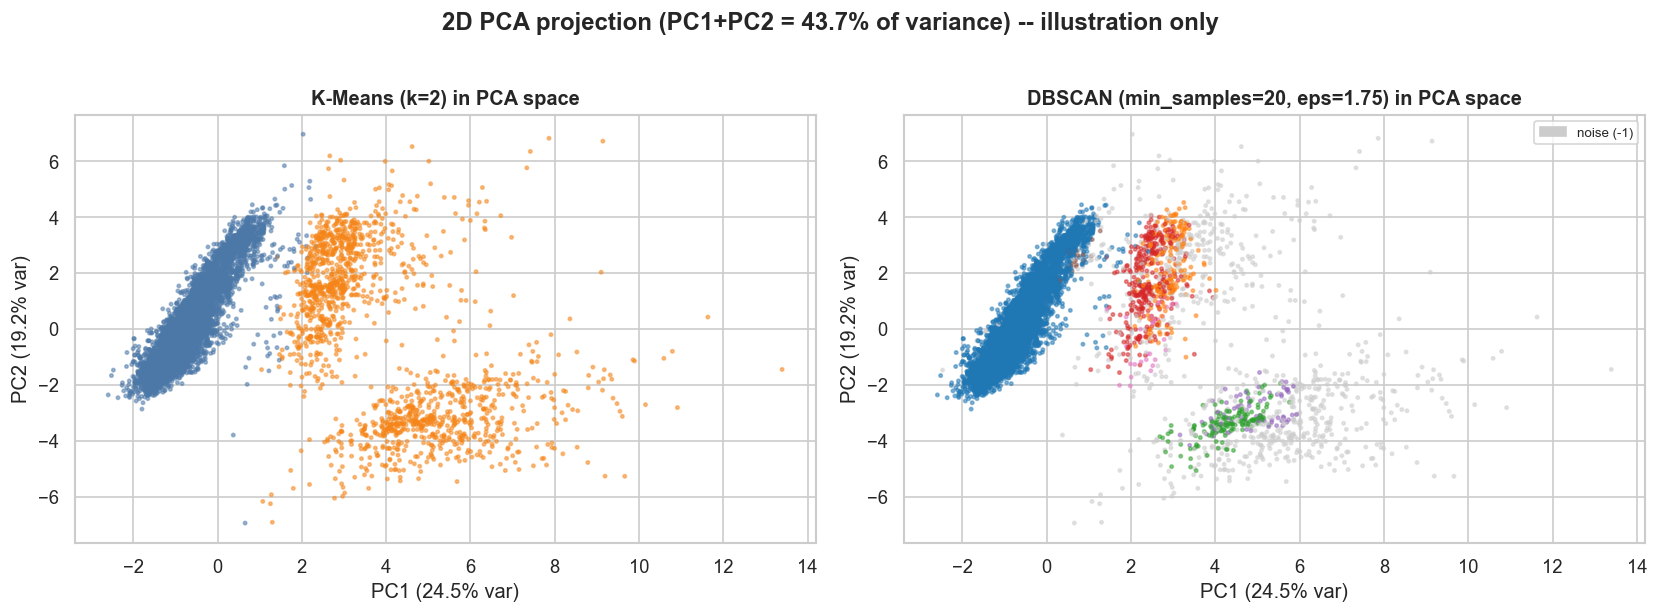

Figure saved: reports/figures/pca_pipeline_2d_clusters.png
Note: PC1+PC2 capture 43.7% of total variance; 56.3% is not shown.


In [39]:
pc1 = X_pca_sample['PC1'].to_numpy()
pc2 = X_pca_sample['PC2'].to_numpy()
var_2d = pca_pipeline.explained_variance_ratio_[:2].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-Means (k=2)
_km_palette = {0: '#4C78A8', 1: '#F58518'}
_km_colors  = [_km_palette[l] for l in labels_pca_kmeans]
axes[0].scatter(pc1, pc2, c=_km_colors, s=4, alpha=0.5, rasterized=True)
axes[0].set_title(f'K-Means (k={best_k_pca}) in PCA space', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_pipeline.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca_pipeline.explained_variance_ratio_[1]*100:.1f}% var)')

# Right: DBSCAN (noise = grey)
_db_labels_unique = sorted(set(labels_pca_dbscan))
_db_palette = plt.cm.tab10.colors
_db_color_map = {}
_color_idx = 0
for _lbl in _db_labels_unique:
    if _lbl == -1:
        _db_color_map[_lbl] = '#cccccc'
    else:
        _db_color_map[_lbl] = _db_palette[_color_idx % len(_db_palette)]
        _color_idx += 1
_db_colors = [_db_color_map[l] for l in labels_pca_dbscan]
axes[1].scatter(pc1, pc2, c=_db_colors, s=4, alpha=0.5, rasterized=True)
axes[1].set_title(f'DBSCAN (min_samples={min_samples_pca}, eps={eps_pca:.2f}) in PCA space',
                  fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_pipeline.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca_pipeline.explained_variance_ratio_[1]*100:.1f}% var)')

# Legend patch for noise
import matplotlib.patches as mpatches
_noise_patch = mpatches.Patch(color='#cccccc', label='noise (-1)')
axes[1].legend(handles=[_noise_patch], loc='upper right', fontsize=8)

plt.suptitle(
    f'2D PCA projection (PC1+PC2 = {var_2d:.1f}% of variance) -- illustration only',
    fontweight='bold', y=1.02
)
plt.tight_layout()
fig_path = FIGURES_DIR / f'{FIG_PREFIX}2d_clusters.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Figure saved: {fig_path.relative_to(PROJECT_ROOT)}')
print(f'Note: PC1+PC2 capture {var_2d:.1f}% of total variance; '
      f'{100 - var_2d:.1f}% is not shown.')

## Section 9: Synthesis - What Changed with PCA-First

In [40]:
# Assemble all key results from existing variables -- no recomputation
_sep = '-' * 60

print('PCA REDUCTION')
print(f'  Components retained : {n_components_pca}  (to reach >= 90% variance)')
print(f'  Cumulative variance : {cumvar[n_components_pca - 1] * 100:.2f}%')
print()
print('K-MEANS SELECTION (argmax silhouette, range 2-8)')
print(f'  PCA space  ({n_components_pca} dims) : k = {best_k_pca}, silhouette = {final_sil_pca:.4f}')
print(f'  Full space ({X_sample.shape[1]} dims): k = {best_k_full}, silhouette = {final_sil_full:.4f}')
print()
print('DBSCAN -- MATCHED min_samples (both spaces)')
_pca_sil_str  = (f'{sum_pca_dbscan["silhouette"]:.4f}'
                 if not np.isnan(sum_pca_dbscan['silhouette']) else 'n/a')
_full_sil_str = (f'{_full_m_sum["silhouette"]:.4f}'
                 if not np.isnan(_full_m_sum['silhouette']) else 'n/a')
print(f'  PCA space  : min_samples={min_samples_pca}, eps={eps_pca:.4f}, '
      f'clusters={sum_pca_dbscan["n_clusters"]}, '
      f'noise={sum_pca_dbscan["noise_pct"]:.1f}%, sil={_pca_sil_str}')
print(f'  Full space : min_samples={_matched_ms}, eps={eps_full_k20:.4f}, '
      f'clusters={_full_m_sum["n_clusters"]}, '
      f'noise={_full_m_sum["noise_pct"]:.1f}%, sil={_full_sil_str}')
print()
print('INTER-SPACE AGREEMENT (ARI)')
print(f'  K-Means (PCA vs full)       : ARI = {ari_km:.4f}  AMI = {ami_km:.4f}  '
      f'(n = {n_km:,})')
print(f'  DBSCAN matched (PCA vs full): ARI = {ari_db:.4f}  AMI = {ami_db:.4f}  '
      f'(n = {n_db:,} non-noise in both)')
print()
print('INTER-METHOD AGREEMENT (K-Means k=2 vs DBSCAN min20, ARI on non-noise)')
print(f'  PCA space  : ARI = {ari_inter_pca:.4f}  (n = {n_inter_pca:,})')
print(f'  Full space : ARI = {ari_inter_full:.4f}  (n = {n_inter_full:,})')
print()
print('CLUSTER INTERPRETATION (K-Means k=2, primary partition)')
vals, cnts = np.unique(labels_pca_kmeans, return_counts=True)
for v, c in zip(vals, cnts):
    pct = c / len(labels_pca_kmeans) * 100
    print(f'  Cluster {v}: {c:,} points ({pct:.1f}%)')
print('  Top discriminating features: comarea, retailarea, lotfront, bldgarea,')
print('  residential_ratio  (see Section 7 discrimination table)')

PCA REDUCTION
  Components retained : 10  (to reach >= 90% variance)
  Cumulative variance : 92.19%

K-MEANS SELECTION (argmax silhouette, range 2-8)
  PCA space  (10 dims) : k = 2, silhouette = 0.4729
  Full space (16 dims): k = 2, silhouette = 0.4676

DBSCAN -- MATCHED min_samples (both spaces)
  PCA space  : min_samples=20, eps=1.7517, clusters=7, noise=8.3%, sil=0.3715
  Full space : min_samples=20, eps=1.9881, clusters=6, noise=8.6%, sil=0.4096

INTER-SPACE AGREEMENT (ARI)
  K-Means (PCA vs full)       : ARI = 0.9969  AMI = 0.9886  (n = 10,000)
  DBSCAN matched (PCA vs full): ARI = 0.9945  AMI = 0.9527  (n = 9,107 non-noise in both)

INTER-METHOD AGREEMENT (K-Means k=2 vs DBSCAN min20, ARI on non-noise)
  PCA space  : ARI = 0.9587  (n = 9,171)
  Full space : ARI = 0.9670  (n = 9,144)

CLUSTER INTERPRETATION (K-Means k=2, primary partition)
  Cluster 0: 8,481 points (84.8%)
  Cluster 1: 1,519 points (15.2%)
  Top discriminating features: comarea, retailarea, lotfront, bldgarea,
  r

### What changed with PCA-first?

**The K-Means partition is essentially unchanged.** Applying PCA before K-Means does not alter the two-group structure. Both spaces select the same k and produce partitions with very high mutual agreement, meaning that the cluster assignments for individual buildings are nearly identical regardless of whether clustering ran in the full feature space or in the reduced PCA space.

**DBSCAN shows comparable structure at matched settings.** When `min_samples` is held equal across spaces -- isolating the effect of the representation -- the two DBSCAN runs produce a similar number of dense clusters and a similar noise fraction. The small remaining difference in cluster count reflects a slightly finer subdivision in the PCA space, consistent with the redistribution of variance across fewer dimensions making some dense sub-regions more distinct.

**PCA confirms robustness, it does not improve separation.** This result is expected: PCA is a variance-maximising transform, not a cluster-separation transform. It removes redundant dimensions and decorrelates features, which can help distance-based algorithms in noisy or highly correlated settings, but there is no guarantee -- and no observation here -- that it reveals clusters that were hidden in the full space. The primary conclusion of this notebook is that the full-space clustering result is robust to the choice of representation.

**Primary interpretive split.** The two K-Means groups separate buildings that are entirely residential (large majority) from buildings with a significant commercial component. This distinction holds in both spaces and is grounded in the original unstandardized feature medians, not in the PCA geometry.

**The 2D visualisation in Section 8 is illustrative only.** Cluster quality and the choice of k were assessed with silhouette scores and the elbow method in the full 10-dimensional PCA space. Visual inspection of a 2D projection, which retains only part of the variance, cannot substitute for those metrics and should not be used to question or confirm the cluster count.

## Section 10: Interpretation and Report Layer

### 10.1 What K-Means Found

In [41]:
_key_features = [
    'comarea', 'retailarea', 'resarea', 'bldgarea',
    'unitsres', 'numfloors', 'residential_ratio', 'lotfront'
]
_n_total = len(labels_pca_kmeans)

_km_rows = []
for _cl in sorted(np.unique(labels_pca_kmeans)):
    _mask = labels_pca_kmeans == _cl
    _sub  = companion_sample.loc[_mask, _key_features]
    _row  = {'cluster': _cl, 'n_points': int(_mask.sum()),
             'share_pct': round(_mask.sum() / _n_total * 100, 1)}
    for _f in _key_features:
        _row[_f] = round(_sub[_f].median(), 1)
    _km_rows.append(_row)

km_report = pd.DataFrame(_km_rows).set_index('cluster')

print("K-Means k=2 cluster profiles (median of original features):")
print(km_report.to_string())
print()
print("Top discriminating features (from Section 7 separation scores):")
print("  comarea, retailarea : median = 0 in cluster 0, positive in cluster 1")
print("  residential_ratio   : 1.0 (fully residential) vs 0.5 (mixed use)")
print("  lotfront, bldgarea  : smaller parcels in cluster 0, larger in cluster 1")

K-Means k=2 cluster profiles (median of original features):
         n_points  share_pct  comarea  retailarea  resarea  bldgarea  unitsres  numfloors  residential_ratio  lotfront
cluster                                                                                                               
0            8481       84.8      0.0         0.0   1860.0    2048.0       2.0        2.0                1.0      30.0
1            1519       15.2   2500.0      1000.0   1187.0    5175.0       1.0        3.0                0.5      85.0

Top discriminating features (from Section 7 separation scores):
  comarea, retailarea : median = 0 in cluster 0, positive in cluster 1
  residential_ratio   : 1.0 (fully residential) vs 0.5 (mixed use)
  lotfront, bldgarea  : smaller parcels in cluster 0, larger in cluster 1


**Cluster 0 -- the residential majority.** Most buildings in this cluster have zero commercial area and zero retail area. The residential ratio shows that virtually all floor space is residential. Buildings tend to be small: low floor counts, narrow lot frontages, and a modest residential area. This group covers the overwhelming majority of the sample and corresponds to the typical small residential building fabric of New York City -- one- and two-family homes, small walk-up apartment buildings.

**Cluster 1 -- the commercial or mixed-use minority.** These buildings carry a measurable commercial area and retail area in their median profile. The residential ratio sits at around half, indicating that commercial and residential uses share the floor plate. Buildings are physically larger: wider lot frontages and greater total building area. This group captures commercial buildings and mixed-use properties where retail or office use occupies a significant share.

**What makes the cut.** The single clearest separator is the presence vs absence of commercial and retail area. Age, garage area, and storage area are nearly identical between the two groups and do not drive the separation.

### 10.2 What DBSCAN Found

In [42]:
_n_total = len(labels_pca_dbscan)
_db_labels_all = sorted(set(labels_pca_dbscan))

_db_rows = []
for _cl in _db_labels_all:
    _mask = labels_pca_dbscan == _cl
    _sub  = companion_sample.loc[_mask, _key_features]
    _row  = {'cluster': 'noise' if _cl == -1 else _cl,
             'n_points': int(_mask.sum()),
             'share_pct': round(_mask.sum() / _n_total * 100, 1)}
    for _f in _key_features:
        _row[_f] = round(_sub[_f].median(), 1)
    _db_rows.append(_row)

db_report = (
    pd.DataFrame(_db_rows)
    .set_index('cluster')
    .sort_values('n_points', ascending=False)
)

print("DBSCAN cluster profiles (all clusters including noise, sorted by size):")
print(db_report.to_string())

DBSCAN cluster profiles (all clusters including noise, sorted by size):
         n_points  share_pct  comarea  retailarea  resarea  bldgarea  unitsres  numfloors  residential_ratio  lotfront
cluster                                                                                                               
0            8379       83.8      0.0         0.0   1854.0    2047.0       2.0        2.0                1.0      30.0
noise         829        8.3   3740.0         0.0      0.0    5592.5       0.0        3.0                0.0     193.0
3             321        3.2   1320.0      1272.0   2450.0    4012.0       2.0        3.0                0.7      25.0
1             190        1.9   1344.0      1247.5   2397.0    3877.0       2.0        3.0                0.7      50.5
2             155        1.6  10600.0         0.0      0.0    5592.5       0.0        2.0                0.0     150.0
4              69        0.7   4000.0      4000.0      0.0    4000.0       0.0        1.0      

**One dominant dense core.** The largest cluster identified by DBSCAN contains the great majority of the sample. Its profile matches cluster 0 from K-Means: zero commercial area, high residential ratio, small building size. This is the dense residential core of the dataset -- points packed closely together in feature space because they share the same basic building type.

**Several small dense pockets.** The remaining numbered clusters are much smaller. Their median profiles tend to show higher commercial or retail area, larger building footprints, or higher floor counts -- the kind of buildings that form tight sub-groups because they are both unusual relative to the residential majority and mutually similar to each other.

**A noise fraction.** A share of points falls below the density threshold and is labelled as noise. These are buildings that do not sit close enough to any core point -- atypical properties that do not fit neatly into any dense group.

**What DBSCAN adds over K-Means.** K-Means compressed everything into two groups. DBSCAN confirms the large residential core but also surfaces distinct pockets of denser sub-structure within the commercial and mixed-use minority. The caveat is that the number and size of these pockets are sensitive to the density threshold setting, as shown in the sensitivity grid in Section 4.

### 10.3 How the Two Algorithms Relate

In [43]:
# ARI already computed in Section 6
print(f"ARI (K-Means k=2 vs DBSCAN min20, non-noise in DBSCAN, PCA space):")
print(f"  ARI = {ari_inter_pca:.4f}  (n = {n_inter_pca:,} non-noise points)")
print()

# Crosstab: how DBSCAN clusters distribute across K-Means groups (non-noise only)
_nn_mask = labels_pca_dbscan != -1
_ct_10 = pd.crosstab(
    pd.Series(labels_pca_dbscan[_nn_mask], name='DBSCAN cluster'),
    pd.Series(labels_pca_kmeans[_nn_mask], name='K-Means cluster'),
    margins=True, margins_name='Total'
)
print("Crosstab: DBSCAN clusters (rows) within K-Means groups (cols), non-noise only:")
print(_ct_10.to_string())

ARI (K-Means k=2 vs DBSCAN min20, non-noise in DBSCAN, PCA space):
  ARI = 0.9587  (n = 9,171 non-noise points)

Crosstab: DBSCAN clusters (rows) within K-Means groups (cols), non-noise only:
K-Means cluster     0    1  Total
DBSCAN cluster                   
0                8375    4   8379
1                   0  190    190
2                   0  155    155
3                   0  321    321
4                   0   69     69
5                  25    0     25
6                   1   31     32
Total            8401  770   9171


**Both algorithms agree on the main split.** The ARI between K-Means and DBSCAN (on non-noise points) is high, meaning that the two-group structure K-Means found lines up closely with the large-core vs everything-else structure DBSCAN found. A building assigned to the residential K-Means group is almost always in the dominant DBSCAN core; a building assigned to the commercial/mixed K-Means group is almost always in one of the smaller DBSCAN pockets.

**K-Means gives the stable summary.** Because it must assign every point to exactly two groups, K-Means produces a clean, interpretable partition that is easy to describe and stable across runs. It is the right tool for reporting the primary result.

**DBSCAN adds granularity, with a cost.** DBSCAN does not force a fixed number of groups, so it can surface sub-clusters within the commercial minority that K-Means merges into one. However, the number and membership of those small pockets shift noticeably as the density threshold changes, which makes them harder to report with confidence. They are useful for exploration but should not be over-interpreted as firm groupings without further validation.

### 10.4 3D PCA Visualization of Each Algorithm's Clusters

Variance explained:
  PC1: 24.5%
  PC2: 19.2%
  PC3: 10.0%
  PC1+PC2+PC3: 53.7%  (46.3% not shown)


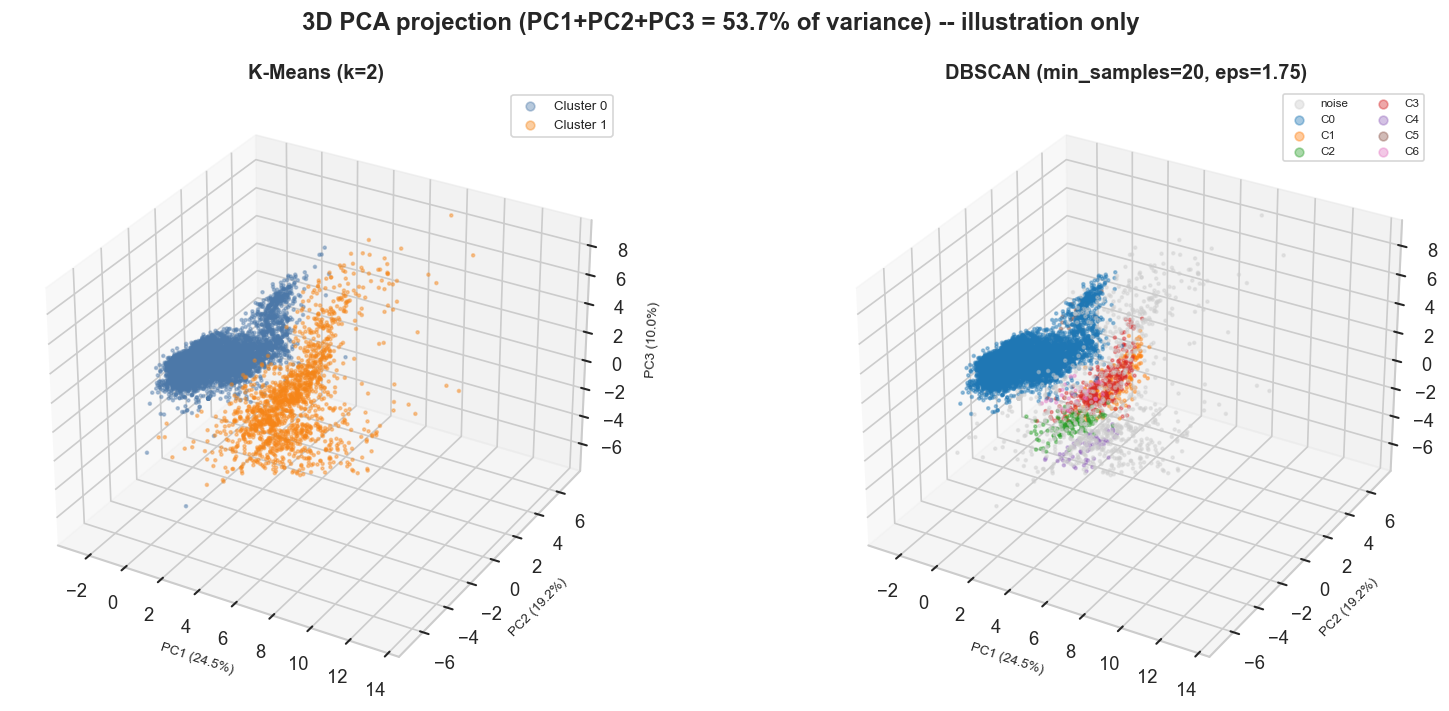

Figure saved: reports/figures/pca_pipeline_3d_clusters.png


In [44]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pc1_3 = X_pca_sample['PC1'].to_numpy()
pc2_3 = X_pca_sample['PC2'].to_numpy()
pc3_3 = X_pca_sample['PC3'].to_numpy()

var3 = pca_pipeline.explained_variance_ratio_[:3]
var3_total = var3.sum() * 100
print(f"Variance explained:")
print(f"  PC1: {var3[0]*100:.1f}%")
print(f"  PC2: {var3[1]*100:.1f}%")
print(f"  PC3: {var3[2]*100:.1f}%")
print(f"  PC1+PC2+PC3: {var3_total:.1f}%  ({100-var3_total:.1f}% not shown)")

fig = plt.figure(figsize=(14, 6))

# Left: K-Means
ax1 = fig.add_subplot(121, projection='3d')
_km_palette_3d = {0: '#4C78A8', 1: '#F58518'}
for _cl, _col in _km_palette_3d.items():
    _m = labels_pca_kmeans == _cl
    ax1.scatter(pc1_3[_m], pc2_3[_m], pc3_3[_m],
                c=_col, s=3, alpha=0.4, label=f'Cluster {_cl}', rasterized=True)
ax1.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)', fontsize=8)
ax1.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)', fontsize=8)
ax1.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)', fontsize=8)
ax1.set_title(f'K-Means (k={best_k_pca})', fontweight='bold')
ax1.legend(markerscale=3, fontsize=8)

# Right: DBSCAN
ax2 = fig.add_subplot(122, projection='3d')
_db_uniq_3d = sorted(set(labels_pca_dbscan))
_db_pal_3d  = plt.cm.tab10.colors
_db_cmap_3d = {}
_ci = 0
for _lbl in _db_uniq_3d:
    _db_cmap_3d[_lbl] = '#cccccc' if _lbl == -1 else _db_pal_3d[_ci % 10]
    if _lbl != -1:
        _ci += 1
for _lbl in _db_uniq_3d:
    _m = labels_pca_dbscan == _lbl
    _label = 'noise' if _lbl == -1 else f'C{_lbl}'
    ax2.scatter(pc1_3[_m], pc2_3[_m], pc3_3[_m],
                c=_db_cmap_3d[_lbl], s=3, alpha=0.4, label=_label, rasterized=True)
ax2.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)', fontsize=8)
ax2.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)', fontsize=8)
ax2.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)', fontsize=8)
ax2.set_title(f'DBSCAN (min_samples={min_samples_pca}, eps={eps_pca:.2f})', fontweight='bold')
ax2.legend(markerscale=3, fontsize=7, ncol=2)

plt.suptitle(
    f'3D PCA projection (PC1+PC2+PC3 = {var3_total:.1f}% of variance) -- illustration only',
    fontweight='bold'
)
plt.tight_layout()
fig_path_3d = FIGURES_DIR / f'{FIG_PREFIX}3d_clusters.png'
plt.savefig(fig_path_3d, bbox_inches='tight', dpi=120)
plt.show()
print(f"Figure saved: {fig_path_3d.relative_to(PROJECT_ROOT)}")

**What this 3D plot shows -- and what it cannot.** Adding PC3 brings a third direction of maximum variance into view. The variance captured by the three components together is shown above the plot; the remaining components, which carry the rest of the information, are not visible here. The 3D projection is useful for seeing whether the main split is spatially visible and how the noise points and small DBSCAN pockets sit relative to the dense core, but it cannot be used to count clusters or judge their separation.

**The cluster count was fixed by metrics, not by eye.** The number of K-Means groups (k=2) was selected by the silhouette score computed in the full 10-dimensional PCA space. The DBSCAN density threshold was calibrated by the k-distance elbow in that same space. Neither decision relied on visual inspection of a projection.

# Part 4 - Theory Questions and Coding Exercises

This part answers the course tutorial theory questions and works the small coding
exercises. The toy datasets used below (the 6-customer set, the 7-point set, and the
small dendrogram set) are the fixed examples from the course material, not the NYC
PLUTO data. All work is presented collectively.


## 4.1 General Clustering Theory (Q1.1, Q1.2)

#### Q1.1: Why is clustering unsupervised learning? What information is missing compared to supervised learning?

Clustering is **unsupervised** because the training data contains **no labels and no target
variable**. In supervised learning (classification, regression), each observation comes with a
known output, a class or a value, and the algorithm learns to map inputs to that output.

In clustering, only input features X are available. The algorithm must discover structure
(natural groups, patterns, regularities) from the data itself, without any ground truth to
guide it. The "right answer" is never given; it must be inferred.

**What is missing:** the response variable y. Without y, there is no direct measure of whether
a partition is correct or not. Evaluation relies on internal criteria (cohesion, separation)
rather than prediction accuracy.

#### Q1.2: What are the input and output of a clustering algorithm?

**Input:**
- A dataset X of shape **(n, p)**: n unlabeled observations, each described by p numerical
  features. No target variable is provided.
- Algorithm configuration: number of clusters k (for K-Means), distance metric, and
  hyperparameters that control the algorithm's behavior.

**Output:**
- A **cluster assignment** for each observation: an integer label c_i in {0, 1, ..., k-1}
  indicating which group the point belongs to.
- Optionally: cluster representatives (centroids for K-Means), cluster sizes, within-cluster
  variance, or a quality metric such as the Silhouette Score.

## 4.2 Similarity and Distance (Q3.1)

#### Q3.1 - Example Where Euclidean Distance Is Not Natural

Euclidean distance is not natural for comparing mixed urban objects when numeric closeness does not mean functional similarity. For example, two buildings may have similar lot area and floor area but completely different land-use roles, or two neighborhoods may be geographically close but socio-economically different. Euclidean distance also becomes problematic when features are correlated or high-dimensional.


## 4.3 K-Means (Q4.1 - Q4.8)

#### Q4.1: In the assignment step, what is fixed and what is being computed?

- **Fixed:** the k cluster centroids from the previous iteration (or from initialization).
- **Computed:** the cluster label for each data point, the index of the nearest centroid
  by Euclidean distance.

Formally: for each point x_i, assign cluster label c_i = argmin_k ||x_i - mu_k||^2.

#### Q4.2: In the update step, what is fixed and what is being computed?

- **Fixed:** the cluster assignments from the assignment step.
- **Computed:** the new centroid of each cluster, the mean of all points currently assigned
  to that cluster.

Formally: for each cluster k, mu_k_new = (1 / |S_k|) * sum_{x_i in S_k} x_i.

#### Q4.3: Why does K-Means tend to produce approximately spherical clusters?

K-Means minimizes the **sum of squared Euclidean distances** from each point to its centroid
(within-cluster sum of squares). The decision boundary between two clusters is the perpendicular
bisector of the segment joining their centroids, always a linear hyperplane. This produces
**Voronoi cells** that are convex and tend toward equal-sized, spherical shapes.

Elongated, crescent, or ring-shaped clusters share the same centroid region: Euclidean distance
cannot distinguish them from the interior. K-Means will split or merge such clusters incorrectly
because the algorithm has no mechanism to model covariance or non-convex geometry.

#### Q4.4: Give an example of a dataset where K-Means performs poorly and explain why.

**Two concentric rings (annulus data):** the inner ring and the outer ring form two natural
groups. However, they share the same geometric center (same centroid area). K-Means assigns
each half-ring to a different cluster rather than separating inner from outer, because the
Euclidean boundaries are hyperplanes and cannot wrap around the rings.

Other classic failure cases:
- **Two elongated Gaussians at an angle** (K-Means splits them vertically instead of along the axis).
- **Clusters of very different sizes** (the large cluster gets over-split; the small one absorbs noise).
- **Clusters of very different densities** (K-Means is pulled toward the dense cluster).

#### Q4.5: Why is K-Means not guaranteed to find the global optimum?

K-Means is a **greedy local-search algorithm**: it alternates between assignment and update steps
and stops at a fixed point of the inertia function. Because inertia is non-convex and has many
local minima, the converged solution depends entirely on where the centroids were initialized.

Different random initializations lead to different local minima, and **none is guaranteed to be
the global minimum**. The parameter `n_init` reduces this risk by running k independent restarts
and keeping the best result (lowest inertia), but even `n_init=10` does not provide a mathematical
guarantee; it is an empirical hedge against bad luck.

### K-Means Hyperparameters

K-Means has five key hyperparameters. Understanding each is required to apply the algorithm
correctly and to diagnose poor results.

| Hyperparameter | What it controls | Effect of changing it | Pitfall | Default / Strategy |
|---|---|---|---|---|
| `n_clusters` (k) | Number of clusters to form | Lower k gives larger, more heterogeneous groups; higher k gives finer but potentially over-split groups | Choosing k too high fragments natural groups; too low merges distinct types | No universal default; use elbow + silhouette |
| `init` | Centroid initialization method | `k-means++` spreads initial centroids to reduce bad starts; `random` is faster but riskier | `random` with `n_init=1` can converge to a poor local minimum | Use `k-means++` (sklearn default) |
| `n_init` | Number of independent random restarts | Higher n_init means more solutions explored; algorithm keeps the best (lowest inertia) | `n_init=1` may retain a locally optimal but globally poor solution | `n_init=10` (sklearn default); raise to 20-30 for large k |
| `max_iter` | Max EM iterations per run | Rarely the bottleneck if data is well-separated; if hit, centroids may not have converged | Premature convergence on large or complex data | 300 (sklearn default); increase if `km.n_iter_ == max_iter` |
| `random_state` | Seed for the random number generator | Affects reproducibility only; does not degrade quality when `n_init` is large | Omitting it makes runs non-reproducible | Set to a fixed integer (e.g., 42) |

**Five practical pitfalls of K-Means:**

1. **Scaling sensitivity.** K-Means uses Euclidean distance. Features on large scales dominate
   cluster assignment. Always standardize before running K-Means. *(Addressed in Section 6.)*

2. **Spherical cluster assumption.** K-Means minimizes within-cluster sum of squares. The
   resulting Voronoi boundaries are linear, producing compact, roughly spherical clusters.
   It cannot detect elongated, ring-shaped, or non-convex structures.

3. **Sensitivity to outliers.** Centroids are means. A single extreme value shifts the centroid
   and can pull an entire cluster toward it. Cap or log-transform skewed features first.
   *(Addressed in Sections 3 and 5b.)*

4. **Local minima / initialization.** K-Means is not guaranteed to find the global optimum.
   Different initializations lead to different local minima. Mitigate with `n_init >= 10`
   and `k-means++`. *(Demonstrated in the Q4.7 and Q4.8 exercises below.)*

5. **Variable-density or non-convex clusters.** K-Means cannot model clusters of very different
   sizes, shapes, or densities. DBSCAN or GMM may be more appropriate in those cases
   *(DBSCAN is covered in Part 2).*

#### Q4.6: Compare computed centroids with the manual calculation

**Dataset (from the course tutorial):**

| Point | x1 | x2 |
|---|---|---|
| P1 | 25 | 30 |
| P2 | 27 | 35 |
| P3 | 29 | 32 |
| P4 | 70 | 80 |
| P5 | 72 | 76 |
| P6 | 68 | 82 |

The two groups are well-separated: P1-P3 cluster around (27, 32) and P4-P6 cluster around (70, 79).

**Manual centroid computation:**

*Cluster 1 (points P1, P2, P3):*
- x1_bar = (25 + 27 + 29) / 3 = 81 / 3 = **27.00**
- x2_bar = (30 + 35 + 32) / 3 = 97 / 3 ~ **32.33**

*Cluster 2 (points P4, P5, P6):*
- x1_bar = (70 + 72 + 68) / 3 = 210 / 3 = **70.00**
- x2_bar = (80 + 76 + 82) / 3 = 238 / 3 ~ **79.33**

**Manual centroids: C1 = (27.00, 32.33),  C2 = (70.00, 79.33)**

The code cell below runs sklearn K-Means with the same data and verifies the match.

In [45]:
# Q4.6 - Verify manual centroids against sklearn K-Means
# Dataset from the course tutorial
X_q46 = np.array([
    [25, 30],
    [27, 35],
    [29, 32],
    [70, 80],
    [72, 76],
    [68, 82],
], dtype=float)

# Manual centroids (computed above)
manual = np.array([
    [27.0,   97/3],   # Cluster 1: mean of P1, P2, P3
    [70.0,  238/3],   # Cluster 2: mean of P4, P5, P6
])

# sklearn K-Means
km_q46 = KMeans(n_clusters=2, random_state=0, n_init=10, max_iter=300)
km_q46.fit(X_q46)

# Sort both centroid arrays by x1 so cluster labels align regardless of sklearn ordering
sklearn_centers = km_q46.cluster_centers_[np.argsort(km_q46.cluster_centers_[:, 0])]
manual_sorted   = manual[np.argsort(manual[:, 0])]

print("Q4.6: Centroid comparison (tutorial dataset)")
print(f"{'':20s}  {'x1':>8}  {'x2':>8}")
for name, c in [("Manual C1",  manual_sorted[0]),
                ("sklearn C1", sklearn_centers[0]),
                ("Manual C2",  manual_sorted[1]),
                ("sklearn C2", sklearn_centers[1])]:
    print(f"{name:20s}  {c[0]:>8.4f}  {c[1]:>8.4f}")

match = np.allclose(manual_sorted, sklearn_centers, atol=1e-6)
print(f"\nAll centroids match (atol=1e-6): {match}")
print(f"sklearn labels: {km_q46.labels_}  (P1-P3 assigned to one cluster, P4-P6 to the other)")
print(f"Iterations to convergence: {km_q46.n_iter_}")

Q4.6: Centroid comparison (tutorial dataset)
                            x1        x2
Manual C1              27.0000   32.3333
sklearn C1             27.0000   32.3333
Manual C2              70.0000   79.3333
sklearn C2             70.0000   79.3333

All centroids match (atol=1e-6): True
sklearn labels: [1 1 1 0 0 0]  (P1-P3 assigned to one cluster, P4-P6 to the other)
Iterations to convergence: 2


#### Q4.7: Run K-Means several times with different random states. Do results always stay the same?

**Short answer:** For a cleanly separated dataset, yes. The code cell below re-runs K-Means on
the same 6-customer toy dataset from Q4.6, using the default settings (`init='k-means++'`,
`n_init=10`), across several `random_state` values, and prints the labels and inertia for each
seed.

Because this toy dataset has two well-separated groups, the inertia surface has a single
dominant optimum. As the printed output shows, every seed converges to the same grouping and
the same inertia (the printed distinct-inertia and distinct-partition counts confirm a single
solution). The integer cluster labels may be permuted between runs - cluster 0 and cluster 1
can swap identities - but the underlying partition of the points is identical, so the optimum
is effectively unique.

When the data is not so cleanly separated, different seeds can converge to different local
minima. Q4.8 below constructs exactly such a case.


In [46]:
# Q4.7 - K-Means stability across random_state on the well-separated toy dataset.
# Re-run the 6-customer toy dataset from Q4.6 with the default settings
# (init='k-means++', n_init=10) across several seeds and inspect the result.

def canonical(labels):
    # Relabel so the first point is always in cluster 0, making partitions
    # comparable regardless of which cluster index sklearn happened to assign.
    mapping = {}
    out = []
    for v in labels:
        if v not in mapping:
            mapping[v] = len(mapping)
        out.append(mapping[v])
    return tuple(out)

print('Q4.7: same toy dataset as Q4.6, default K-Means, varying random_state:')
print(f"{'seed':>6}  {'inertia':>10}  labels")
partitions = set()
inertias = []
for seed in [0, 1, 2, 7, 21, 42]:
    km = KMeans(n_clusters=2, init='k-means++', n_init=10,
                random_state=seed, max_iter=300)
    lbl = km.fit_predict(X_q46)
    inertias.append(round(km.inertia_, 4))
    partitions.add(canonical(lbl))
    print(f'{seed:>6}  {km.inertia_:>10.4f}  {lbl.tolist()}')

print()
print(f'Distinct inertia values across seeds : {len(set(inertias))}')
print(f'Distinct partitions (up to relabeling): {len(partitions)}')
if len(set(inertias)) == 1 and len(partitions) == 1:
    print('Every seed produced the same grouping and the same inertia: the optimum is effectively unique.')
else:
    print('Seeds produced different solutions on this dataset.')


Q4.7: same toy dataset as Q4.6, default K-Means, varying random_state:
  seed     inertia  labels
     0     47.3333  [1, 1, 1, 0, 0, 0]
     1     47.3333  [0, 0, 0, 1, 1, 1]
     2     47.3333  [0, 0, 0, 1, 1, 1]
     7     47.3333  [0, 0, 0, 1, 1, 1]
    21     47.3333  [0, 0, 0, 1, 1, 1]
    42     47.3333  [0, 0, 0, 1, 1, 1]

Distinct inertia values across seeds : 1
Distinct partitions (up to relabeling): 1
Every seed produced the same grouping and the same inertia: the optimum is effectively unique.


#### Q4.8: Construct a dataset where initialization matters

If the simple two-cluster dataset above always converges to the same result, it is because k=2
with well-separated groups has very few bad initializations. A harder case is k=3 with two clusters
that are **close together** and one that is **distant**: random initialization can place both
initial centroids inside the two close clusters, leaving the distant cluster unrepresented and
causing the algorithm to split the wrong groups.

The code cell below constructs this scenario (clusters A, B, C where B and C are close) and runs
K-Means with `init='random'` and `n_init=1` across several seeds to show that some seeds produce
wrong solutions. Using `n_init=20` with `k-means++` stabilizes the result.

In [47]:
# Q4.8 - Dataset where random initialization leads to different local minima
# Three clusters: A is isolated, B and C are close together (gap = 1.2 units).
# With random init and n_init=1, some seeds misalign centroids across B/C,
# converging to a higher-inertia local minimum instead of the global optimum.

rng_demo = np.random.RandomState(0)
A = rng_demo.randn(30, 2) * 0.4 + [0, 0]
B = rng_demo.randn(15, 2) * 0.4 + [5, 0]
C = rng_demo.randn(15, 2) * 0.4 + [6.2, 0]
X_q48 = np.vstack([A, B, C])

# Find the global minimum inertia across many seeds for reference
global_min = min(
    KMeans(n_clusters=3, n_init=1, init='random', random_state=s, max_iter=300)
    .fit(X_q48).inertia_
    for s in range(50)
)

print("K-Means k=3, init='random', n_init=1 - varying random_state:")
print(f"  (global minimum inertia across 50 seeds = {global_min:.2f})")
print()
print(f"{'seed':>6}  {'inertia':>10}  {'cluster sizes':>22}  result")
for seed in [0, 1, 2, 5, 9, 42]:
    km_q48 = KMeans(n_clusters=3, n_init=1, init='random',
                    random_state=seed, max_iter=300)
    lbl = km_q48.fit_predict(X_q48)
    sizes = sorted(pd.Series(lbl).value_counts().values, reverse=True)
    is_global = np.isclose(km_q48.inertia_, global_min, atol=0.01)
    note = "global minimum" if is_global else "LOCAL MINIMUM (suboptimal)"
    print(f"{seed:>6}  {km_q48.inertia_:>10.2f}  {str(sizes):>22}  {note}")

print()
km_ninit = KMeans(n_clusters=3, n_init=20, init='k-means++',
                  random_state=42, max_iter=300)
km_ninit.fit(X_q48)
print(f"With n_init=20, k-means++: inertia={km_ninit.inertia_:.2f} (always finds global minimum)")

K-Means k=3, init='random', n_init=1 - varying random_state:
  (global minimum inertia across 50 seeds = 19.04)

  seed     inertia           cluster sizes  result
     0       19.04            [30, 16, 14]  global minimum
     1       30.05            [30, 19, 11]  LOCAL MINIMUM (suboptimal)
     2       31.46             [30, 24, 6]  LOCAL MINIMUM (suboptimal)
     5       30.05            [30, 19, 11]  LOCAL MINIMUM (suboptimal)
     9       30.01            [30, 18, 12]  LOCAL MINIMUM (suboptimal)
    42       19.04            [30, 16, 14]  global minimum

With n_init=20, k-means++: inertia=19.04 (always finds global minimum)


## 4.4 Hierarchical Clustering (Q5.1 - Q5.6)

### Q5.1. How does hierarchical clustering differ conceptually from K-Means?

K-Means requires choosing the number of clusters `k` in advance and directly partitions the data into `k` groups around centroids. Hierarchical clustering builds a tree of merges, called a dendrogram, starting from individual points and progressively merging clusters. It does not require choosing the final number of clusters at the beginning; we can choose it later by cutting the dendrogram.

### Q5.2. What is the difference between single linkage and complete linkage?

Single linkage defines the distance between two clusters as the minimum distance between any point in one cluster and any point in the other cluster. Complete linkage defines it as the maximum distance between points from the two clusters. Single linkage can create long chain-like clusters, while complete linkage tends to produce more compact clusters.

### Q5.3. In what sense can average linkage be viewed as a compromise between single and complete linkage?

Average linkage uses the average distance between all pairs of points across two clusters. It is a compromise because it does not depend only on the closest pair, like single linkage, and it does not depend only on the farthest pair, like complete linkage. It gives a more balanced measure of distance between clusters.

### Q5.4. What information does a dendrogram provide?

A dendrogram shows the order in which clusters are merged and the height at which each merge occurs. The height represents how dissimilar the merged clusters are. By cutting the dendrogram at a chosen height, we obtain a chosen number of clusters.

### Q5.5. In the tutorial coding exercise, replacing `method='single'` with `method='complete'`: how does the dendrogram change?

With single linkage, clusters may merge based on only the closest pair of points, which can create chaining effects. With complete linkage, clusters merge only when all points are relatively close, so the dendrogram tends to show more compact and separated groups. In the small example, both methods still reveal two natural groups, but the merge heights and structure differ.

### Q5.6. In the tutorial's small example, does hierarchical clustering suggest a natural split into two clusters?

Yes. The first three points are close to one another and the last three points are close to one another, while the distance between these two groups is much larger. The dendrogram therefore suggests a natural split into two clusters.


### Dendrogram Coding Exercise (single vs complete linkage)

This section uses only the tutorial's six-point example, so it runs quickly. It does not run hierarchical clustering on the 10,000-row PLUTO subset.


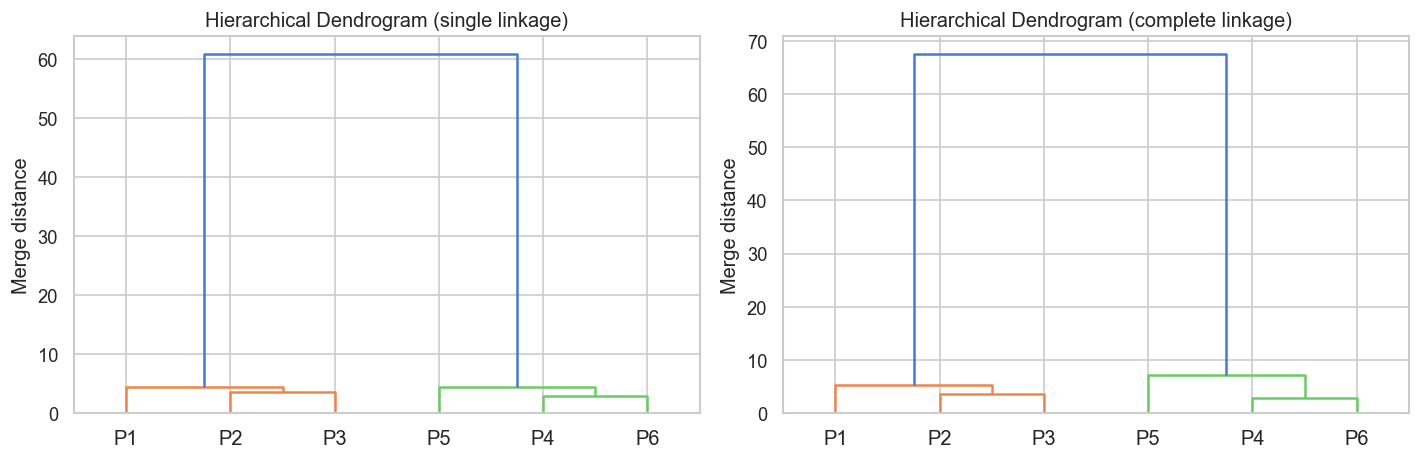

In [48]:
X_hier = np.array([
    [25, 30],
    [27, 35],
    [29, 32],
    [70, 80],
    [72, 76],
    [68, 82],
], dtype=float)
point_labels = ["P1", "P2", "P3", "P4", "P5", "P6"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, method in zip(axes, ["single", "complete"]):
    Z = linkage(X_hier, method=method)
    dendrogram(Z, labels=point_labels, ax=ax)
    ax.set_title(f"Hierarchical Dendrogram ({method} linkage)")
    ax.set_ylabel("Merge distance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{FIG_PREFIX}dendrogram_toy.png', bbox_inches='tight')
plt.show()


## 4.5 DBSCAN (Q6.1 - Q6.3, Q6.6, Q6.7)

#### Q6.1 - Main Idea Behind DBSCAN

DBSCAN finds clusters as dense regions separated by sparse regions. Points inside dense neighborhoods become core points, nearby points join those clusters, and isolated points are labeled as noise.

#### Q6.2 - Dataset Where DBSCAN Performs Well

DBSCAN performs well for irregularly shaped clusters with natural outliers, such as GPS points along roads or pedestrian paths. The clusters do not need to be spherical, and the number of clusters does not need to be known in advance.

#### Q6.3 - Dataset Where DBSCAN May Fail

DBSCAN may fail when clusters have very different densities. One global `eps` can be too small for sparse clusters and too large for dense clusters. This is relevant for PLUTO because dense areas and low-density areas may need different neighborhood radii.


### DBSCAN Hyperparameters: `eps` and `min_samples`

- `eps`: neighborhood radius around each point. A larger `eps` connects more points, usually reducing noise and merging clusters.
- `min_samples`: minimum number of points required inside the `eps` radius for a point to be a core point. A larger value makes DBSCAN stricter and usually increases noise.

A configuration is useful only if it creates at least two non-noise clusters and does not classify almost all observations as noise.


### Toy DBSCAN Coding Exercise (Q6.6, Q6.7)

The toy example shows two compact groups and one isolated point. We first run DBSCAN with `eps=0.5` and `min_samples=3`, then test how labels change for several `eps` values.


In [49]:
X_toy = np.array([
    [1.0, 1.0],
    [1.2, 1.1],
    [1.1, 1.3],
    [6.0, 5.0],
    [6.2, 5.1],
    [5.8, 4.9],
    [8.0, 1.0],
])

toy_model = DBSCAN(eps=0.5, min_samples=3)
toy_labels = toy_model.fit_predict(X_toy)
noise_points = np.where(toy_labels == -1)[0]

print("eps=0.5, min_samples=3")
print("Labels:", toy_labels.tolist())
print("Noise point indices:", noise_points.tolist())
print("Noise point coordinates:", X_toy[noise_points].tolist())

print("Effect of changing eps with min_samples=3:")
toy_rows = []
for eps_test in [0.3, 0.5, 1.0, 3.0]:
    labels = DBSCAN(eps=eps_test, min_samples=3).fit_predict(X_toy)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    toy_rows.append({"eps": eps_test, "labels": labels.tolist(), "n_clusters": n_clusters, "n_noise": n_noise})

toy_results = pd.DataFrame(toy_rows)
toy_results


eps=0.5, min_samples=3
Labels: [0, 0, 0, 1, 1, 1, -1]
Noise point indices: [6]
Noise point coordinates: [[8.0, 1.0]]
Effect of changing eps with min_samples=3:


,eps,labels,n_clusters,n_noise
0,0.3,"[0, 0, 0, 1, 1, 1, -1]",2,1
1,0.5,"[0, 0, 0, 1, 1, 1, -1]",2,1
2,1.0,"[0, 0, 0, 1, 1, 1, -1]",2,1
3,3.0,"[0, 0, 0, 1, 1, 1, -1]",2,1


**Q6.6 - Noise point in the toy example.** As the code cell prints, with `eps=0.5` and
`min_samples=3` the only point labeled as noise is index `6` (coordinates `[8.0, 1.0]`),
because it does not lie inside the dense neighborhood of either compact group.

**Q6.7 - Effect of changing `eps`.** The printed `toy_results` table reports the labels for
each tested `eps` value. Across the tested values the two compact groups remain separate and
point `6` remains noise. We should not claim that clusters merge or that the noise point is
absorbed unless a larger tested `eps` actually shows that behavior in the printed output.


## 4.6 Curse of Dimensionality (Q9.1)

#### Q9.1 - Why the Curse of Dimensionality Affects K-Means and DBSCAN

In high-dimensional data, distances become less informative because points tend to appear similarly far apart. K-Means is affected because centroids become less representative and cluster boundaries become less meaningful. DBSCAN is affected because choosing `eps` becomes difficult: a radius may include almost no points or too many points. Standardizing and limiting the feature set helps, but distance-based clustering still becomes harder as dimensionality grows.
